# Init

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Setup
import yaml
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

In [3]:
from src.feedbackqa.regression import FeedbackQARegressionRunner
from src.feedbackqa.diagnostics import collect_all_diagnostics, extract_diagnostic_table, overview

from src.general_analysis.engine import AnalysisEnvironment
from src.general_analysis.reliability import ReliabilityAnalyzer

from src.prompt_manager import PromptManager

from src.utils import interactive_dataframe_selector, interactive_regression_results_selector, interactive_plot_viewer

# Load data

In [4]:
env = AnalysisEnvironment(
    active_analysis='mcgill_qa_feedback', sandbox_mode=False)

# Load everything
# models_to_include: ['Qwen-Qwen3.5-4B', 'meta-llama-Llama-3.2-3B-Instruct']
final_df, og_df = env.load_data(use_cache=True, force_refresh=False)
pm, prompt_map = env.load_prompts()


prompt_hash_map = {
    key: item.metadata['description']
    for key, item in pm.suites.items()
}

Loading files for analysis McGill Feedback Analysis
⚡ Loading cached DataFrame from C:\Users\Wouter Barter\Documents\AI_thesis\results\MCGILL_QA_FEEDBACK\MCGILL_QA_FEEDBACK_analysis_ready.pkl...
PromptManager initialized with folder: ..\prompts\PromptSuites\MCGILL_QA_FEEDBACK
Scanning 6 suites from ..\prompts\PromptSuites\MCGILL_QA_FEEDBACK...
Loaded 6 PromptSuites


# Data Pre-processing

## Human readable cols

In [5]:
# Human readable prompt names

prompt_map_clean = {'f926cb88b5c8': 'Holistic Naive',
                    'f1ea5fbc4957': 'Holistic Informed', '83fb9645af53': 'Formative'}
final_df['prompt_name'] = final_df['prompt_id'].map(prompt_map_clean)

# Analysis group concatenation
final_df['analysis_group'] = final_df['model_name'] + \
    "_" + final_df['prompt_id']
final_df['analysis_group_full'] = final_df['model_name'] + "_" + \
    final_df['prompt_id'] + "_" + final_df['dimension_name']
final_df['analysis_group_named'] = final_df['model_name'] + \
    "_" + final_df['prompt_name'] + "_" + final_df['prompt_id']


# Human readable model col
model_map_clean = {
    'google/gemma-4-E2B-it': "Gemma 4",
    'meta-llama/Llama-3.2-3B-Instruct': "Llama 3.2",
    'Qwen/Qwen3-4B-Instruct-2507': "Qwen 3",
    'Qwen/Qwen3.5-4B': "Qwen 3.5"
}
final_df['model_name_clean'] = final_df['model_name'].map(model_map_clean)

# Human readable dimension col
dim_map_clean = {
    'qa_pair_topical_alignment': 'Topical Alignment',
    'qa_pair_information_coverage': 'Information Coverage',
    'qa_pair_topical_concentration': 'Topical Concentration',
    'qa_pair_communicative_clarity': 'Communicative Clarity',
    'qa_pair_overall_answer_quality': 'Overall Quality'
}
final_df['dimension_name_clean'] = final_df['dimension_name'].map(
    dim_map_clean)

final_df.loc[final_df['prompt_id'] == 'f1ea5fbc4957',
             'dimension_name_clean'] = 'Overall Quality (Informed)'
final_df.loc[final_df['prompt_id'] == 'f926cb88b5c8',
             'dimension_name_clean'] = 'Overall Quality (Naive)'


# Human readable analysis group/ experimental group
final_df['analysis_group_full_clean'] = final_df['model_name_clean'] + \
    ": " + final_df['dimension_name_clean'] + \
    "(" + final_df['prompt_name'] + ")"

## Extra features

In [6]:
# Input length
final_df['raw_input_length'] = final_df['question'].apply(
    len) + final_df['answer'].apply(len)

# Fill NaNs to prevent errors, split by whitespace, and count the list length
q_words = final_df['question'].fillna('').str.split().str.len()
a_words = final_df['answer'].fillna('').str.split().str.len()

final_df['question_word_count'] = q_words
final_df['answer_word_count'] = a_words
final_df['raw_input_word_count'] = q_words + a_words

final_df['log_raw_input_word_count'] = np.log1p(
    final_df['raw_input_word_count'])


final_df['length_bucket'] = pd.qcut(final_df['raw_input_word_count'], q=4,
                                    labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

final_df['answer_length_bucket'] = pd.qcut(final_df['answer_word_count'], q=4,
                                           labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

# Final EDA

## Mean, SD of human scores

In [7]:
pd.concat([og_df['score_1'], og_df['score_2']]).mean()

np.float64(2.4729178157749585)

In [8]:
pd.concat([og_df['score_1'], og_df['score_2']]).std()

np.float64(1.2463904008178122)

## Distribution of EV and Entropy

In [9]:
# from src.general_analysis.visualisations import plot_single_dimension_rating_distribution_by_model_pdf
# fig = plot_single_dimension_rating_distribution_by_model_pdf(
#     final_df=final_df,
#     dimension_name='Overall Quality (Naive)',
#     model_order=['Gemma 4', 'Llama 3.2', 'Qwen 3', 'Qwen 3.5'],
#     title=None,
#     rating_range=(1, 4),
#     save_path='../latex_thesis/figures/single_dimension_rating_regimes_feedbackqa.pdf'
# )

In [10]:
from src.general_analysis.tables import rating_entropy_distribution
mean_entr_distribution = rating_entropy_distribution(final_df)


print(mean_entr_distribution.to_latex(
    column_format='lcc',
    caption='Scale Utilization and Entropy Calibration by Model Architecture.',
    label='tab:scale_utilization_barter',
    escape=False
))

\begin{table}
\caption{Scale Utilization and Entropy Calibration by Model Architecture.}
\label{tab:scale_utilization_barter}
\begin{tabular}{lcc}
\toprule
 & Rating: Mean (SD) & Entropy: Mean (SD) \\
Model &  &  \\
\midrule
Gemma 4 & 2.54 (0.74) & 0.13 (0.18) \\
Llama 3.2 & 2.72 (0.77) & 0.72 (0.23) \\
Qwen 3 & 2.95 (0.88) & 0.12 (0.16) \\
Qwen 3.5 & 2.66 (0.67) & 0.73 (0.15) \\
\bottomrule
\end{tabular}
\end{table}



In [11]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

In [12]:
plot_order = list(dim_map_clean.values())


fig = plot_rating_distributions_by_architecture(
    final_df=final_df,
    plot_order=plot_order,
    dim_map_clean=dim_map_clean,
    score_col='mean_rating',
    rating_range=(1, 4),
    save_path='../latex_thesis/figures/feedbackqa_rating_distributions.pdf',
    show=False
)

## Verbosity bias

In [13]:
from src.general_analysis.tables import verbosity_bias_table, summarize_verbosity_bias

sections = {
    'Total Input': 'raw_input_word_count'}

verbosity_df = verbosity_bias_table(
    df=final_df,
    sections=sections,
    min_abs_d=0  # only medium or larger effects
)
# verbosity_df

verbosity_summary = summarize_verbosity_bias(
    bias_df=verbosity_df,
    model_col="Model",
    abs_d_col="Absolute Cohen's d",
    combine_medium_large=False
)

print(
    verbosity_summary.to_latex(
        index=False,
        escape=False,
        column_format="lccccccc",
        caption="Summary of FeedbackQA Verbosity-Bias Diagnostics",
        label="tab:verbosity_bias_feedbackqa"
    )
)

\begin{table}
\caption{Summary of FeedbackQA Verbosity-Bias Diagnostics}
\label{tab:verbosity_bias_feedbackqa}
\begin{tabular}{lccccccc}
\toprule
Model & Mean $|d|$ & Max $|d|$ & N & Negligible & Small & Medium & Large \\
\midrule
Gemma 4 & 0.16 & 0.20 & 6 & 5 & 1 & 0 & 0 \\
Llama 3.2 & 0.57 & 0.62 & 6 & 0 & 0 & 6 & 0 \\
Qwen 3 & 0.15 & 0.25 & 6 & 4 & 2 & 0 & 0 \\
Qwen 3.5 & 0.11 & 0.25 & 6 & 5 & 1 & 0 & 0 \\
\bottomrule
\end{tabular}
\end{table}



## VIF

In [14]:
final_df[final_df['prompt_name'] == 'Formative']

,question,passage,feedback,rating,domain,source_file,review_1,explanation_1,review_2,explanation_2,...,model_name_clean,dimension_name_clean,analysis_group_full_clean,raw_input_length,question_word_count,answer_word_count,raw_input_word_count,log_raw_input_word_count,length_bucket,answer_length_bucket
0,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Topical Alignment,Gemma 4: Topical Alignment(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
1,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Information Coverage,Gemma 4: Information Coverage(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
2,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Topical Concentration,Gemma 4: Topical Concentration(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
3,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Communicative Clarity,Gemma 4: Communicative Clarity(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
6,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Llama 3.2,Topical Alignment,Llama 3.2: Topical Alignment(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217647,Why do we need to stay active during lockdown ...,"{'passage_id': 44, 'reference': {'page_title':...",[This is a direct answer to the question. this...,"[Excellent, Could be Improved, Bad]",WHO,test,Excellent,This is a direct answer to the question. this ...,Could be Improved,This answer talks more about the benefits of p...,...,Qwen 3,Communicative Clarity,Qwen 3: Communicative Clarity(Formative),860,11,121,132,4.890349,3. Medium-Long,3. Medium-Long
217650,Why do we need to stay active during lockdown ...,"{'passage_id': 44, 'reference': {'page_title':...",[This is a direct answer to the question. this...,"[Excellent, Could be Improved, Bad]",WHO,test,Excellent,This is a direct answer to the question. this ...,Could be Improved,This answer talks more about the benefits of p...,...,Qwen 3.5,Topical Alignment,Qwen 3.5: Topical Alignment(Formative),860,11,121,132,4.890349,3. Medium-Long,3. Medium-Long
217651,Why do we need to stay active during lockdown ...,"{'passage_id': 44, 'reference': {'page_title':...",[This is a direct answer to the question. this...,"[Excellent, Could be Improved, Bad]",WHO,test,Excellent,This is a direct answer to the question. this ...,Could be Improved,This answer talks more about the benefits of p...,...,Qwen 3.5,Information Coverage,Qwen 3.5: Information Coverage(Formative),860,11,121,132,4.890349,3. Medium-Long,3. Medium-Long
217652,Wh

In [15]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_mean = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    covariates=['log_raw_input_word_count'],
    include_entropy=False,       # now adds entropy_* cols to iv_cols
    mode="rating",
    model_col='model_name_clean'
)

vif_df = runner_mean.compute_vifs(
    df=final_df[final_df['prompt_name'] == 'Formative'])

In [16]:
from src.general_analysis.diagnostics import compact_vif_threshold_summary

vif_table = compact_vif_threshold_summary(vif_df).copy()

# Optional: make labels thesis-clean
vif_table["Group"] = (
    vif_table["Group"]
    .str.replace("_", " ", regex=False)
)

latex_vif_table = vif_table.to_latex(
    index=False,
    column_format="lccrrl",
    caption="VIF Diagnostics for FeedbackQA Formative Specifications",
    label="tab:VIF_feedbackqa",
    escape=False
)

print(latex_vif_table)

\begin{table}
\caption{VIF Diagnostics for FeedbackQA Formative Specifications}
\label{tab:VIF_feedbackqa}
\begin{tabular}{lccrrl}
\toprule
Group & Max VIF & Mean VIF & N VIF > 5 & N VIF > 10 & Multicollinearity \\
\midrule
Gemma 4 Formative & 6.75 & 4.46 & 3 & 0 & Moderate \\
Llama 3.2 Formative & 16.93 & 9.43 & 4 & 2 & Substantial \\
Qwen 3.5 Formative & 11.39 & 6.88 & 4 & 1 & Substantial \\
Qwen 3 Formative & 9.38 & 6.86 & 4 & 0 & Moderate \\
\bottomrule
\end{tabular}
\end{table}



# General EDA

In [17]:
plot_order = list(dim_map_clean.values())


prompt_order = ['Holistic Naive', 'Holistic Informed', 'Formative']

## Distribrution across rating scale

In [18]:
combined_scores = pd.concat(
    [og_df['score_1'], og_df['score_2']], ignore_index=True)

In [ ]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (1, 4)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, dim_map_clean=dim_map_clean, score_col='mean_rating', rating_range=rating_range)

## Correlation matrix

In [ ]:
# Pivot the table so each dimension is a column, and each row is a Q&A pair
pivot_df = final_df.pivot(
    index='input_id',  # Or whatever your document ID column is named
    columns='analysis_group_full_clean',
    values='normalized_entropy'
)

# Now calculate the correlation matrix
corr_matrix = pivot_df.corr()

display(corr_matrix)

analysis_group_full_clean,Gemma 4: Communicative Clarity(Formative),Gemma 4: Information Coverage(Formative),Gemma 4: Overall Quality (Informed)(Holistic Informed),Gemma 4: Overall Quality (Naive)(Holistic Naive),Gemma 4: Topical Alignment(Formative),Gemma 4: Topical Concentration(Formative),Llama 3.2: Communicative Clarity(Formative),Llama 3.2: Information Coverage(Formative),Llama 3.2: Overall Quality (Informed)(Holistic Informed),Llama 3.2: Overall Quality (Naive)(Holistic Naive),...,Qwen 3.5: Overall Quality (Informed)(Holistic Informed),Qwen 3.5: Overall Quality (Naive)(Holistic Naive),Qwen 3.5: Topical Alignment(Formative),Qwen 3.5: Topical Concentration(Formative),Qwen 3: Communicative Clarity(Formative),Qwen 3: Information Coverage(Formative),Qwen 3: Overall Quality (Informed)(Holistic Informed),Qwen 3: Overall Quality (Naive)(Holistic Naive),Qwen 3: Topical Alignment(Formative),Qwen 3: Topical Concentration(Formative)
analysis_group_full_clean,,,,,,,,,,,,,,,,,,,,,
Gemma 4: Communicative Clarity(Formative),1.000000,0.307876,0.347015,0.373071,0.197968,0.219245,0.084731,0.038861,0.045750,0.092717,...,0.152407,0.134737,0.108478,0.175781,-0.007774,0.036429,0.064948,0.048245,0.068541,0.051891
Gemma 4: Information Coverage(Formative),0.307876,1.000000,0.594067,0.489466,0.307807,0.331402,0.141967,0.148067,0.149399,0.179670,...,0.217625,0.205546,0.170913,0.209052,-0.032908,0.049346,0.080247,0.079434,0.072166,0.049410
Gemma 4: Overall Quality (Informed)(Holistic Informed),0.347015,0.594067,1.000000,0.660006,0.395294,0.413874,0.084286,0.067468,0.072818,0.107483,...,0.197311,0.179321,0.161652,0.211425,-0.043779,0.019464,0.037069,0.027201,0.049177,0.030716
Gemma 4: Overall Quality (Naive)(Holistic Naive),0.373071,0.489466,0.660006,1.000000,0.339882,0.374484,0.064464,0.036185,0.045997,0.086076,...,0.155207,0.134189,0.118205,0.172768,-0.037268,0.010833,0.015611,0.004048,0.043895,0.025711
Gemma 4: Topical Alignment(Formative),0.197968,0.307807,0.395294,0.339882,1.000000,0.599280,0.068098,0.073033,0.078697,0.097482,...,0.207332,0.195077,0.209328,0.216388,-0.031806,0.020580,0.029279,0.024445,0.032743,0.016843
Gemma 4: Topical Concentration(Formative),0.219245,0.331402,0.413874,0.374484,0.599280,1.000000,0.066158,0.061766,0.069648,0.094759,...,0.184493,0.164287,0.185019,0.216162,-0.026454,0.023371,0.033603,0.019983,0.035120,0.018473
Llama 3.2: Communicative Clarity(Formative),0.084731,0.141967,0.084286,0.064464,0.068098,0.066158,1.000000,0.850453,0.837761,0.857458,...,0.194074,0.209445,0.168289,0.142153,0.004297,0.087619,0.119669,0.118471,0.095762,0.070672
Llama 3.2: Information Coverage(Formative),0.038861,0.148067,0.067468,0.036185,0.073033,0.061766,0.850453,1.000000,0.924226,0.906543,...,0.226414,0.250064,0.207559,0.165553,-0.006882,0.107809,0.132553,0.134696,0.117625,0.080515
Llama 3.2: Overall Quality (Informed)(Holistic Informed),0.045750,0.149399,0.072818,0.045997,0.078697,0.069648,0.837761,0.924226,1.000000,0.918174,...,0.210830,0.228007,0.194071,0.159231,-0.014348,0.094454,0.127351,0.124973,0.113378,0.084306


## Verbosity bias (relationship between input length and rating)

### Ceiling effect

In [ ]:
from src.general_analysis.visualisations import plot_verbosity_grid

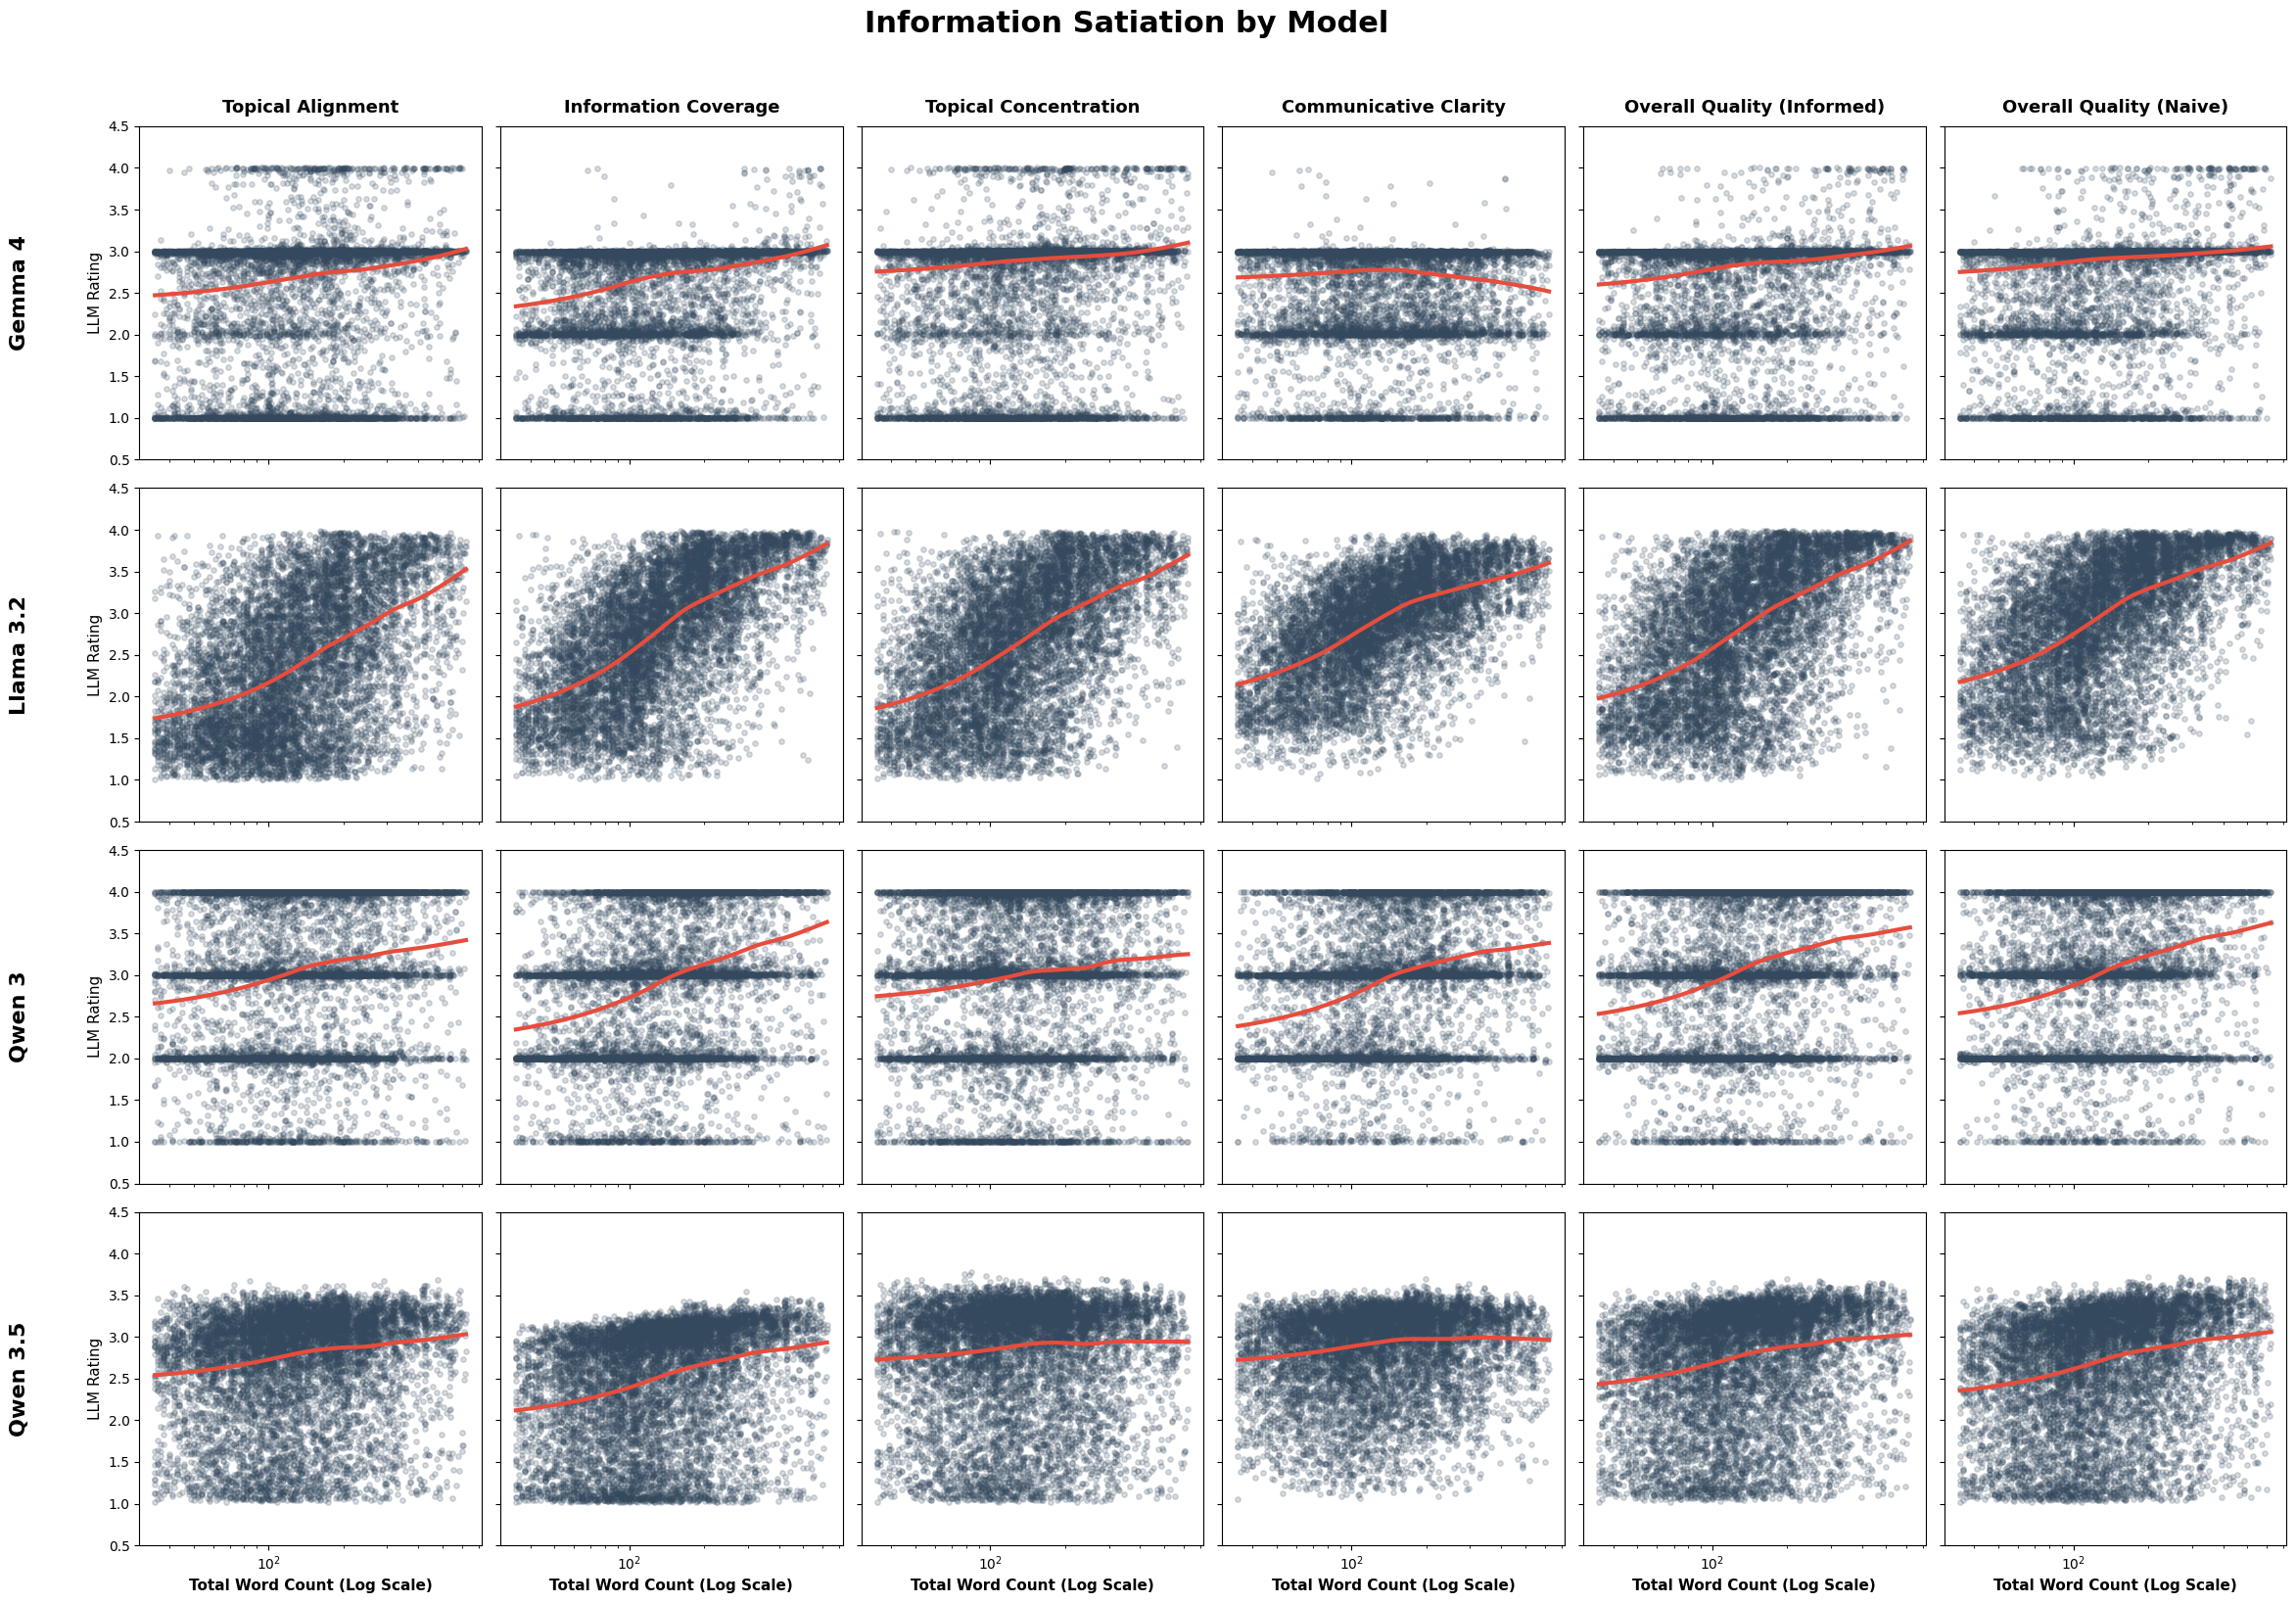

In [ ]:
models = final_df['model_name_clean'].unique()
dimensions = final_df['dimension_name_clean'].unique()
plot_verbosity_grid(final_df,
                    models=models,
                    dimensions=dimensions,
                    model_col='model_name_clean',
                    dim_col='dimension_name_clean',
                    x_col='raw_input_word_count',
                    y_col='mean_rating',
                    lower_truncate_pct=0.02,
                    upper_truncate_pct=0.98,
                    y_min=0.5, y_max=4.5)

C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:334: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=res_df, x='Text Section', y='Absolute Cohen\'s d', hue='Model',


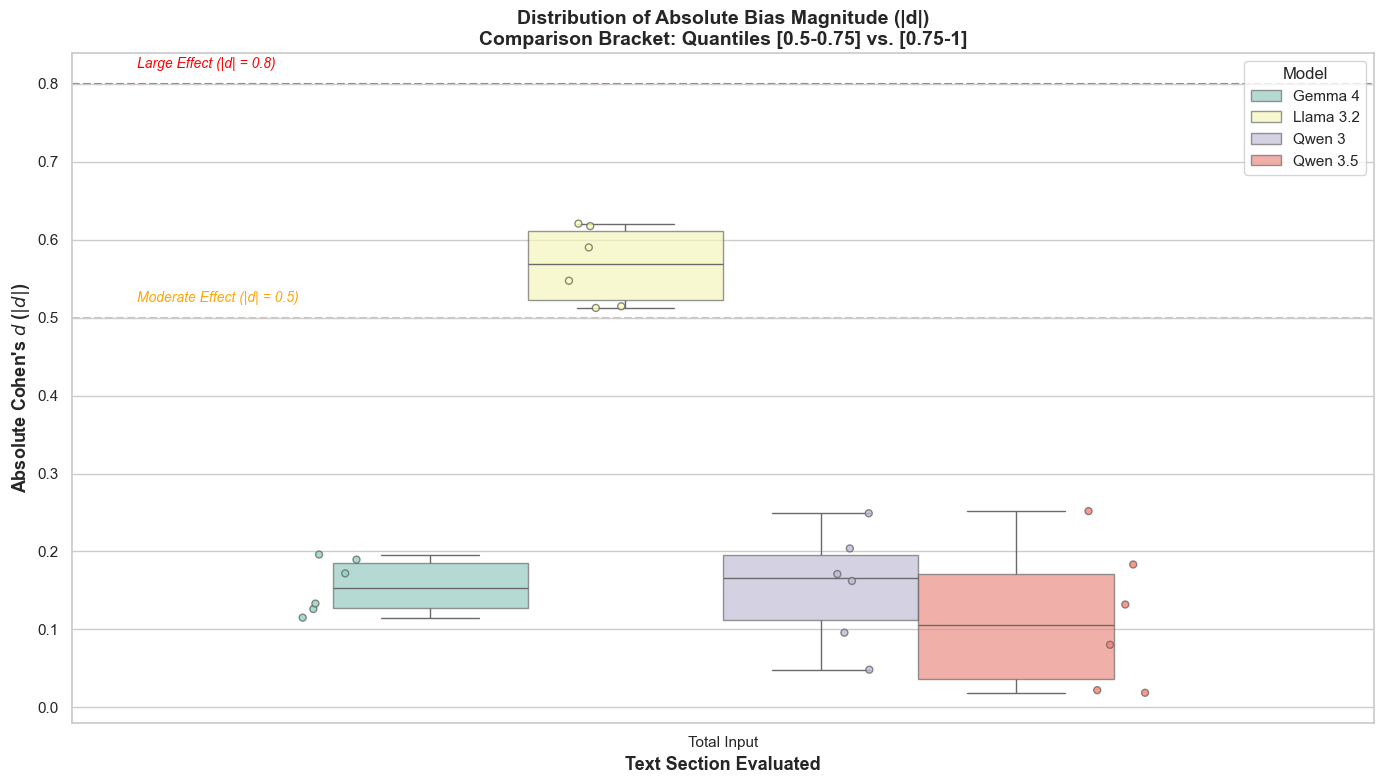

In [ ]:
from src.general_analysis.visualisations import plot_absolute_bias_spread

sections = {
    'Total Input': 'raw_input_word_count'}

res_df_upperquart = plot_absolute_bias_spread(final_df, sections, p_lower=[
    0.5, 0.75], p_upper=[0.75, 1])

## Entropy

### Distribution

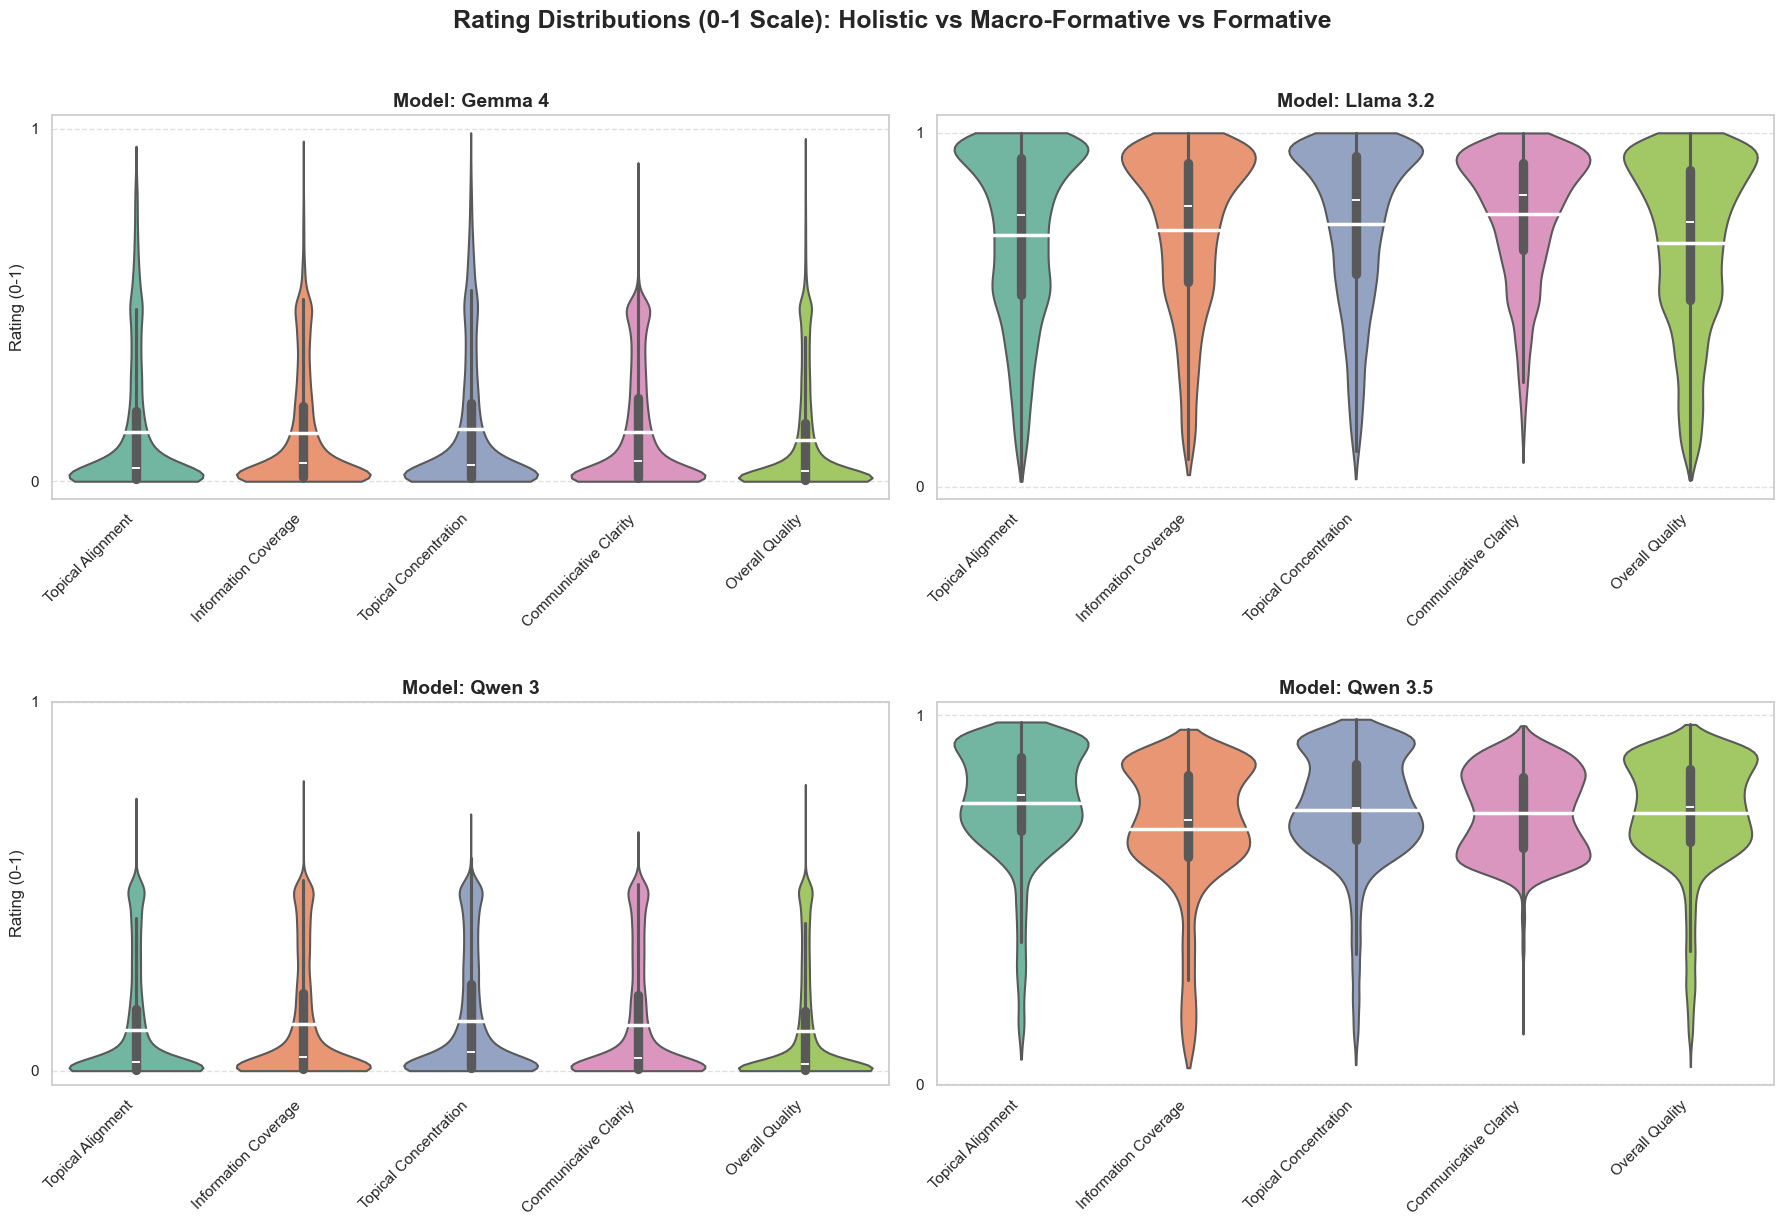

In [ ]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (0, 1)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, score_col='normalized_entropy', rating_range=(0, 1), dim_map_clean=dim_map_clean)

##  Inter-rater reliability

In [ ]:
analyzer = ReliabilityAnalyzer(final_df, group_cols=[
                               'model_name', 'prompt_id', 'dimension_name'], llm_rating_col='mean_rating')
analyzer.compute_reliability_gap(metric='spearman')

,model_name,prompt_id,dimension_name,metric_type,spearman_gap,spearman_hh,spearman_llm_avg
1,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_information_coverage,Spearman,-0.031385,0.540923,0.572308
7,Qwen/Qwen3.5-4B,83fb9645af53,qa_pair_information_coverage,Spearman,-0.030364,0.540923,0.571287
4,Qwen/Qwen3-4B-Instruct-2507,f1ea5fbc4957,qa_pair_overall_answer_quality,Spearman,-0.026085,0.540923,0.567008
2,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_topical_alignment,Spearman,-0.022182,0.540923,0.563105
5,Qwen/Qwen3-4B-Instruct-2507,f926cb88b5c8,qa_pair_overall_answer_quality,Spearman,-0.019690,0.540923,0.560612
11,Qwen/Qwen3.5-4B,f926cb88b5c8,qa_pair_overall_answer_quality,Spearman,-0.015557,0.540923,0.556480
10,Qwen/Qwen3.5-4B,f1ea5fbc4957,qa_pair_overall_answer_quality,Spearman,-0.012948,0.540923,0.553871
3,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_topical_concentration,Spearman,0.000002,0.540923,0.540921
8,Qwen/Qwen3.5-4B,83fb9645af53,qa_pair_topical_alignment,Spearman,0.002026,0.540923,0.538897
0,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_communicative_clarity,Spearman,0.005356,0.540923,0.535567


Because the permutation tests are based on paired out-of-fold predictions, even small improvements can be statistically significant. We therefore interpret statistical significance together with the absolute change in Spearman's $\rho$. The formative condition improves rank-order alignment relative to the naive baseline across all model families, but the magnitude of the improvement is bounded by the relatively high performance of the holistic baselines and the moderate human-human agreement in the dataset.

The FeedbackQA results should be interpreted in light of the human-human reference. The two human annotations correlate at approximately $\rho = 0.54$, while the Qwen holistic baselines already reach a similar level of alignment with the human annotations. This leaves limited headroom for the formative specifications to improve the global correlation metrics. The relatively small incremental gains from formative decomposition therefore do not necessarily imply that decomposition is uninformative; rather, the task provides a noisy and partially saturated benchmark.

A second explanation is the high collinearity among the FeedbackQA formative dimensions. Although Topical Alignment, Information Coverage, Topical Concentration, and Communicative Clarity are conceptually distinct, the dataset often presents cases where these dimensions fail together. In particular, topically mismatched answers are likely to receive low scores across several criteria. As a result, the formative measurements contain limited unique variance beyond the holistic score, reducing the potential gain from decomposition.

This differs from the Barter Deals setting, where Deal Attractiveness is more clearly shaped by opposing forces. A Deal may offer high reward but impose high workload, or have a prestigious brand but a weak call-to-action. In such cases, decomposition is more likely to reveal distinct predictive signals that are obscured by a holistic score.


Overall, the FeedbackQA results provide evidence for the formative measurement framework, but the effect size is modest. The formative condition improves rank-order alignment relative to the naive baseline across model families, yet the gains are constrained by two features of the task. First, the strongest holistic baselines already approach the human-human reference level, leaving limited headroom for improvement. Second, the formative dimensions are highly correlated in this dataset, limiting the amount of unique variance that decomposition can recover. The entropy extensions produce statistically detectable but small incremental gains, suggesting that most of the out-of-sample alignment is captured by the EV measurements.

The fact that some LLM specifications reach human-human levels of rank correlation indicates that they capture a substantial portion of the stable document-level quality signal. However, human-human agreement reflects the reliability of a single annotation, not a strict performance ceiling. Moreover, aggregate correlations can obscure localized failure modes, especially cases where human annotators apply near-veto penalties for topical mismatch.

# Regression

## Mean

In [ ]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_mean = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    covariates=['log_raw_input_word_count'],
    include_entropy=False,       # now adds entropy_* cols to iv_cols
    mode="rating",
    model_col='model_name_clean'
)
runner_mean.run_regression(final_df)

diagnostics_mean = collect_all_diagnostics(runner_mean)
ov_mean = overview(diagnostics_mean)

✓ Gemma 4_Formative | n=18126 | AIC=54693.12
✓ Gemma 4_Holistic Informed | n=18126 | AIC=55241.29
✓ Gemma 4_Holistic Naive | n=18126 | AIC=55519.76
✓ Llama 3.2_Formative | n=18126 | AIC=55812.71
✓ Llama 3.2_Holistic Informed | n=18126 | AIC=56306.91
✓ Llama 3.2_Holistic Naive | n=18126 | AIC=56321.66
✓ Qwen 3_Formative | n=18126 | AIC=52091.79
✓ Qwen 3_Holistic Informed | n=18126 | AIC=52808.60
✓ Qwen 3_Holistic Naive | n=18126 | AIC=52998.24
✓ Qwen 3.5_Formative | n=18126 | AIC=52117.71
✓ Qwen 3.5_Holistic Informed | n=18126 | AIC=52658.78
✓ Qwen 3.5_Holistic Naive | n=18126 | AIC=52613.78


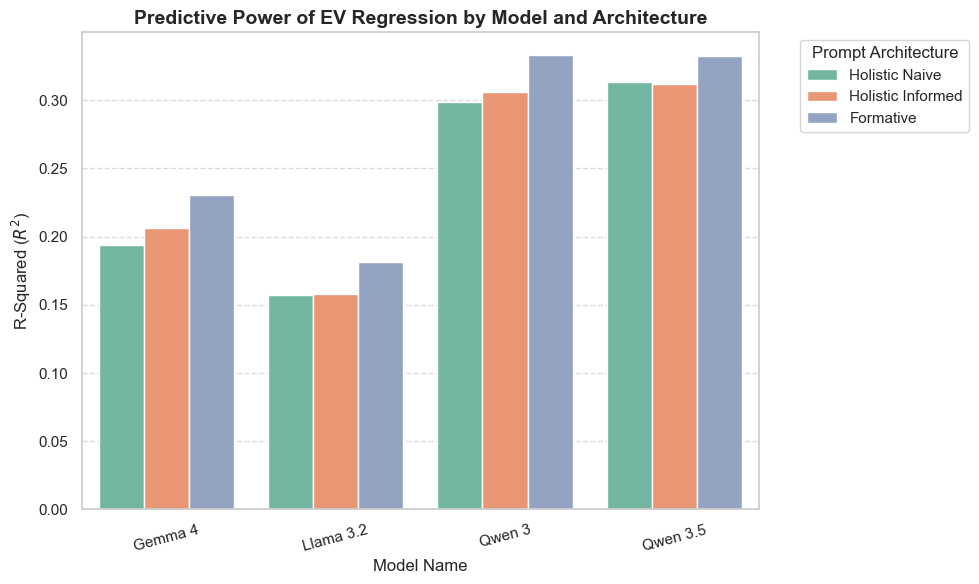

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [ ]:
from src.feedbackqa.visualisations import plot_ev_regression_r2

df_results = ov_mean['metrics']
plot_ev_regression_r2(df_results)

In [ ]:
interactive_dataframe_selector(ov_mean)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('metrics', 'coefficients', 'vif'…

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,Gemma 4_Formative,18126.0,0.230169,0.229956,NaN,54693.121461,54739.952077,-27340.560731,63.793078,6.213968
1,Gemma 4_Holistic Informed,18126.0,0.206269,0.206181,NaN,55241.290100,55264.705408,-27617.645050,42.147221,1.225243
2,Gemma 4_Holistic Naive,18126.0,0.193981,0.193892,NaN,55519.757047,55543.172355,-27756.878523,42.836553,1.237154
3,Llama 3.2_Formative,18126.0,0.181119,0.180893,NaN,55812.709823,55859.540439,-27900.354912,65.984041,10.119759
4,Llama 3.2_Holistic Informed,18126.0,0.158207,0.158114,NaN,56306.907974,56330.323282,-28150.453987,41.760155,1.872585
5,Llama 3.2_Holistic Naive,18126.0,0.157522,0.157429,NaN,56321.658750,56345.074057,-28157.829375,41.992996,1.863292
6,Qwen 3_Formative,18126.0,0.333088,0.332904,NaN,52091.794980,52138.625596,-26039.897490,63.472128,7.623504
7,Qwen 3_Holistic Informed,18126.0,0.305957,0.305880,NaN,52808.598235,52832.013543,-26401.299117,43.063066,1.338482
8,Qwen 3_Holistic Naive,18126.0,0.298657,0.298580,NaN,52998.240000,53021.655308,-26496.120000,42.970828,1.353520
9,Qwen 3.5_Formative,18126.0,0.332134,0.331950,NaN,52117.708115,52164.538731,-26052.854057,76.257976,7.935938


In [ ]:
interactive_regression_results_selector(runner_mean.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     1028.
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        14:04:45   Log-Likelihood:                -27341.
No. Observations:               18126   AIC:                         5.469e+04
Df Residuals:                   18120   BIC:                         5.474e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                        -0.8163      0.076    -10.803      0.000      -0.964      -0.668
mean_rating_qa_pair_communicative_clarity     0.1029      0.026      3.962      0.000       0.052       0.154
mean_rating_qa_pair_information_coverage      0.2985      0.031      9.532      0.000       0.237       0.360
mean_rating_qa_pair_topical_alignment         0.3706      0.030     12.375      0.000       0.312       0.429
mean_rating_qa_pair_topical_concentration    -0.0330      0.032     -1.034      0.301      -0.096       0.030
log_raw_input_word_count                      0.2953      0.015     19.601      0.000       0.266       0.325
==============================================================================
Omnibus:                     2498.028   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              647.523
Skew:                          -0.114   Prob(JB):                    2.47e-141
Kurtosis:                       2.102   Cond. No.                         63.8
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [ ]:
runner_mean.compute_vifs()

,group,predictor,vif,flagged
0,Gemma 4_Formative,mean_rating_qa_pair_topical_concentration,6.751,True
1,Gemma 4_Formative,mean_rating_qa_pair_topical_alignment,6.367,True
2,Gemma 4_Formative,mean_rating_qa_pair_information_coverage,5.065,True
3,Gemma 4_Formative,mean_rating_qa_pair_communicative_clarity,2.950,False
4,Gemma 4_Formative,log_raw_input_word_count,1.185,False
5,Gemma 4_Holistic Informed,mean_rating,1.042,False
6,Gemma 4_Holistic Informed,log_raw_input_word_count,1.042,False
7,Gemma 4_Holistic Naive,mean_rating,1.046,False
8,Gemma 4_Holistic Naive,log_raw_input_word_count,1.046,False
9,Llama 3.2_Formative,mean_rating_qa_pair_information_coverage,16.931,True


## Models including entropy

I settle upon the log raw input word count as opposed to the length bucket, since the results were nearly the same (delta AIC <4), and the normalized condition number is higher for the length bucket. This indicates that a log transformed length is sufficient to account for the model dynamics of text length.

In [ ]:
runner_mean_entr = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    include_entropy=True,
    mode="rating",
    covariates=['log_raw_input_word_count'],
    categorical_covariates=[],
    model_col='model_name_clean'
)
runner_mean_entr.run_regression(final_df)

# interactive_regression_results_selector(runner_mean_entr.results)

diagnostics_mean_entr = collect_all_diagnostics(runner_mean_entr)
ov_mean_entr = overview(diagnostics_mean_entr)
interactive_dataframe_selector(ov_mean_entr)

✓ Gemma 4_Formative | n=18126 | AIC=54476.14
✓ Gemma 4_Holistic Informed | n=18126 | AIC=55039.13
✓ Gemma 4_Holistic Naive | n=18126 | AIC=55322.49
✓ Llama 3.2_Formative | n=18126 | AIC=55676.41
✓ Llama 3.2_Holistic Informed | n=18126 | AIC=56306.72
✓ Llama 3.2_Holistic Naive | n=18126 | AIC=56304.16
✓ Qwen 3_Formative | n=18126 | AIC=52078.23
✓ Qwen 3_Holistic Informed | n=18126 | AIC=52809.30
✓ Qwen 3_Holistic Naive | n=18126 | AIC=52997.94
✓ Qwen 3.5_Formative | n=18126 | AIC=51961.50
✓ Qwen 3.5_Holistic Informed | n=18126 | AIC=52540.06
✓ Qwen 3.5_Holistic Naive | n=18126 | AIC=52524.31


Dropdown(description='Select option:', layout=Layout(width='400px'), options=('metrics', 'coefficients', 'vif'…

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,Gemma 4_Formative,18126.0,0.239665,0.239287,NaN,54476.135781,54554.186808,-27228.067891,64.723963,6.597476
1,Gemma 4_Holistic Informed,18126.0,0.215159,0.215029,NaN,55039.130876,55070.351286,-27515.565438,42.924726,1.262056
2,Gemma 4_Holistic Naive,18126.0,0.202793,0.202662,NaN,55322.485413,55353.705824,-27657.242707,44.143395,1.305836
3,Llama 3.2_Formative,18126.0,0.187612,0.187209,NaN,55676.409757,55754.460784,-27828.204879,123.068216,11.368459
4,Llama 3.2_Holistic Informed,18126.0,0.158309,0.158169,NaN,56306.717296,56337.937707,-28149.358648,53.512601,2.000210
5,Llama 3.2_Holistic Naive,18126.0,0.158427,0.158288,NaN,56304.160851,56335.381261,-28148.080425,58.860995,2.073036
6,Qwen 3_Formative,18126.0,0.333881,0.333550,NaN,52078.226655,52156.277682,-26029.113328,64.643481,7.763603
7,Qwen 3_Holistic Informed,18126.0,0.306006,0.305892,NaN,52809.296156,52840.516566,-26400.648078,44.344393,1.368667
8,Qwen 3_Holistic Naive,18126.0,0.298746,0.298630,NaN,52997.937859,53029.158270,-26494.968930,43.760779,1.358061
9,Qwen 3.5_Formative,18126.0,0.338157,0.337828,NaN,51961.501450,52039.552476,-25970.750725,145.751360,8.604679


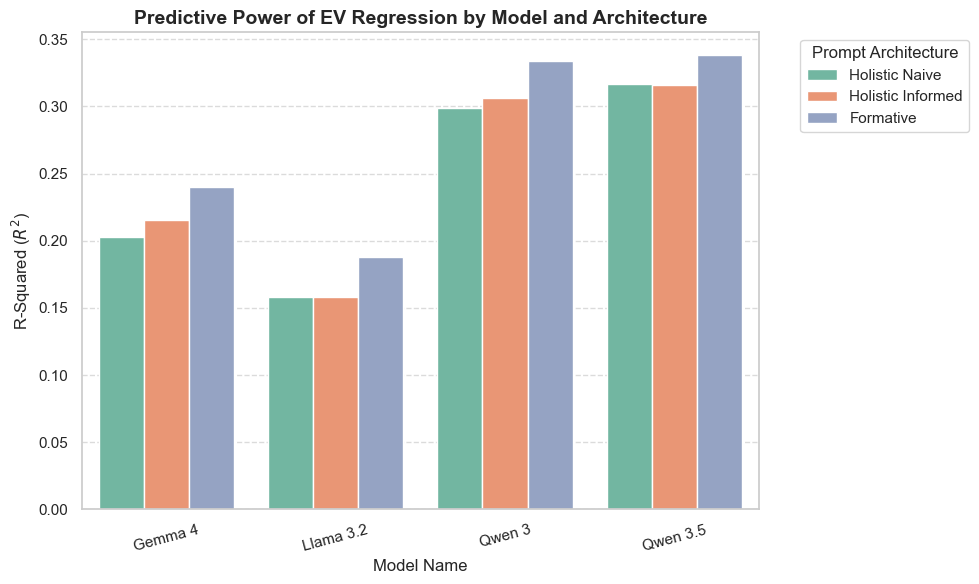

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [ ]:
# Load your results
df_results = ov_mean_entr['metrics']

# Render it interactively
plot_ev_regression_r2(df_results)

In [ ]:
interactive_regression_results_selector(runner_mean_entr.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     576.5
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        14:04:50   Log-Likelihood:                -27228.
No. Observations:               18126   AIC:                         5.448e+04
Df Residuals:                   18116   BIC:                         5.455e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
====================================================================================================================
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
const                                               -0.6779      0.075     -9.014      0.000      -0.825      -0.530
mean_rating_qa_pair_communicative_clarity            0.1130      0.026      4.340      0.000       0.062       0.164
mean_rating_qa_pair_information_coverage             0.2980      0.032      9.434      0.000       0.236       0.360
mean_rating_qa_pair_topical_alignment                0.2961      0.031      9.559      0.000       0.235       0.357
mean_rating_qa_pair_topical_concentration            0.0179      0.033      0.548      0.584      -0.046       0.082
normalized_entropy_qa_pair_communicative_clarity    -0.0551      0.062     -0.888      0.375      -0.177       0.067
normalized_entropy_qa_pair_information_coverage     -0.4878      0.065     -7.542      0.000      -0.615      -0.361
normalized_entropy_qa_pair_topical_alignment        -0.3572      0.063     -5.668      0.000      -0.481      -0.234
normalized_entropy_qa_pair_topical_concentration     0.0306      0.065      0.473      0.636      -0.096       0.157
log_raw_input_word_count                             0.2979      0.015     19.772      0.000       0.268       0.327
==============================================================================
Omnibus:                     1688.484   Durbin-Watson:                   1.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              528.244
Skew:                          -0.090   Prob(JB):                    1.96e-115
Kurtosis:                       2.183   Cond. No.                         64.7
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

Explaining the coefficients and signs for the Entropy Variables:

Instead of guessing why it happens, you simply report that it happens, and use it to prove that LLM measurement is complex and dimension-specific.

State the Heterogeneity: Acknowledge that the "ambiguity penalty" (the negative effect of entropy) is not a universal constant; it varies depending on the semantic construct being measured.

Refuse Speculation: Explicitly state that without a qualitative, text-by-text analysis of what the LLM considers "high entropy" for these specific criteria, any behavioral interpretation is speculative.

Pivot to Future Research: Use this anomaly as a natural segue into the limitations and future research section.


Construct Heterogeneity and Boundary Conditions of Entropy

*"While structural entropy functioned as a significant penalty for dimensions such as Information Coverage and Topical Alignment, the combined models revealed positive entropy coefficients for Communicative Clarity (β=0.27) and Topical Concentration (β=0.30) under the Qwen 3.5 specification.

This divergence indicates that the behavioral effect of structural ambiguity is not uniformly negative but exhibits construct heterogeneity. Because this thesis strictly tests the quantitative validity of LLM measurements, imposing a behavioral or semantic interpretation on these positive coefficients—without a corresponding qualitative analysis of the underlying high-entropy and low-entropy texts—would be highly speculative. Therefore, we restrict our conclusion to the empirical observation that the directional impact of LLM entropy is dimension-dependent. Determining the exact textual features that trigger positive versus negative entropy effects for specific psychometric criteria remains a necessary avenue for future qualitative research."*

ultimate point: You cannot evaluate a text with an LLM using only the first moment (the mean). You must use both moments to separate quality from complexity.

In [ ]:
runner_mean_entr.compute_vifs()

,group,predictor,vif,flagged
0,Gemma 4_Formative,mean_rating_qa_pair_topical_concentration,7.071,True
1,Gemma 4_Formative,mean_rating_qa_pair_topical_alignment,6.920,True
2,Gemma 4_Formative,mean_rating_qa_pair_information_coverage,5.119,True
3,Gemma 4_Formative,mean_rating_qa_pair_communicative_clarity,2.983,False
4,Gemma 4_Formative,normalized_entropy_qa_pair_topical_concentration,1.703,False
5,Gemma 4_Formative,normalized_entropy_qa_pair_topical_alignment,1.636,False
6,Gemma 4_Formative,normalized_entropy_qa_pair_information_coverage,1.265,False
7,Gemma 4_Formative,normalized_entropy_qa_pair_communicative_clarity,1.208,False
8,Gemma 4_Formative,log_raw_input_word_count,1.206,False
9,Gemma 4_Holistic Informed,mean_rating,1.055,False


Construct Purification via Structural Entropy

*"Comparative analysis of the baseline (mean-only) and combined (mean + entropy) models across Qwen 3, Qwen 3.5, and Gemma 4 revealed pervasive suppression effects, demonstrating that first-moment LLM outputs are systematically contaminated by structural ambiguity.

Most notably, in the baseline specification, the LLM rating for 'Communicative Clarity' yielded spurious negative (Gemma 4: z=−2.35) or insignificant (Qwen 3.5: z=−0.05) correlations with human evaluation scores. This indicates a severe omitted variable bias, likely due to the LLM conflating semantic clarity with structural triviality. However, introducing the normalized entropy vectors induced classical suppression: it mathematically partialled out the ambiguity confound, unmasking the true positive behavioral signal of clarity across the models (Gemma 4 unmasked to z=4.34; Qwen 3.5 unmasked to z=2.74), accompanied by dramatic improvements in model fit (ΔAICGemma​=75).

These sign flips establish a profound methodological imperative: the first moment of an LLM evaluation cannot be trusted in isolation. Without the second moment (entropy) acting as an econometric purifier, regressions will yield type-II errors or structurally inverted coefficients. This severely limits the scientific utility of closed-API models in psychometric research, as they inherently deny researchers access to the distributional variance required to unmask the true economic signal."*

In [ ]:
# import gc
# del final_df
# gc.collect()

# Cross-validation

In [ ]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator

# 1. Ensure metrics and predictions are cached
validator = FeedbackQACrossValidator(runner_mean)
cv_results = validator.evaluate_models(n_splits=5)

## Permutation tests for significance

In [ ]:
# 2. Execute Batch Tests for Spearman's rho
# Test 1: Does Formative strictly beat the Informed Baseline? (Mechanism Isolation)
df_sig_informed = validator.batch_test_structural_delta(
    base_suffix="Holistic Informed",
    test_suffix="Formative",
    metric="spearman"
)

# Test 2: Does Formative beat the Naive Baseline? (Total Pipeline Improvement)
df_sig_naive = validator.batch_test_structural_delta(
    base_suffix="Holistic Naive",
    test_suffix="Formative",
    metric="spearman"
)


--- FORMATIVE vs. HOLISTIC NAIVE ---


,Base,Test,p_value_spearman,Significant (p<0.05)
Model,,,,
Gemma 4,Holistic Naive,Formative,0.0001,*
Llama 3.2,Holistic Naive,Formative,0.0001,*
Qwen 3,Holistic Naive,Formative,0.0001,*
Qwen 3.5,Holistic Naive,Formative,0.0001,*


In [ ]:
# # 3. Display Results
# print("--- FORMATIVE vs. HOLISTIC INFORMED ---")
display(df_sig_informed)

print("\n--- FORMATIVE vs. HOLISTIC NAIVE ---")
display(df_sig_naive)

,Base,Test,p_value_spearman,Significant (p<0.05)
Model,,,,
Gemma 4,Holistic Informed,Formative,0.0001,*
Llama 3.2,Holistic Informed,Formative,0.0001,*
Qwen 3,Holistic Informed,Formative,0.0001,*
Qwen 3.5,Holistic Informed,Formative,0.0001,*



--- FORMATIVE vs. HOLISTIC NAIVE ---


,Base,Test,p_value_spearman,Significant (p<0.05)
Model,,,,
Gemma 4,Holistic Naive,Formative,0.0001,*
Llama 3.2,Holistic Naive,Formative,0.0001,*
Qwen 3,Holistic Naive,Formative,0.0001,*
Qwen 3.5,Holistic Naive,Formative,0.0001,*


## Main crossvalidation: out-of-fold metrics

In [ ]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator
from src.feedbackqa.diagnostics import generate_feedbackqa_cv_latex_table

validator_mean = FeedbackQACrossValidator(runner_mean)

cv_mean = validator_mean.evaluate_models(n_splits=5)

human_base = validator_mean.compute_human_baseline(
    og_df,
    score_col_1="score_1",
    score_col_2="score_2"
)

latex_table = generate_feedbackqa_cv_latex_table(
    cv_mean=cv_mean,
    human_base=human_base,
    caption="Cross-Validated Convergent Validity Performance on FeedbackQA",
    label="tab:feedbackqa_cv"
)

print(latex_table)

\begin{table}
\caption{Cross-Validated Convergent Validity Performance on FeedbackQA}
\label{tab:feedbackqa_cv}
\begin{tabular}{llcccc}
\toprule
Model & Condition & RMSE $\downarrow$ & Pearson's $r$ $\uparrow$ & Spearman's $\rho$ $\uparrow$ & Kendall's $\tau$ $\uparrow$ \\
\midrule
Gemma 4 & Holistic Naive & 1.119 & 0.440 & 0.436 & 0.336 \\
Gemma 4 & Holistic Informed & 1.111 & 0.454 & 0.450 & 0.347 \\
Gemma 4 & Formative & 1.094 & 0.479 & 0.480 & 0.370 \\
Llama 3.2 & Holistic Naive & 1.144 & 0.396 & 0.395 & 0.302 \\
Llama 3.2 & Holistic Informed & 1.144 & 0.397 & 0.396 & 0.302 \\
Llama 3.2 & Formative & 1.128 & 0.424 & 0.423 & 0.323 \\
Qwen 3 & Holistic Naive & 1.044 & 0.546 & 0.544 & 0.421 \\
Qwen 3 & Holistic Informed & 1.039 & 0.553 & 0.550 & 0.426 \\
Qwen 3 & Formative & 1.018 & 0.577 & 0.578 & 0.449 \\
Qwen 3.5 & Holistic Naive & 1.033 & 0.559 & 0.559 & 0.435 \\
Qwen 3.5 & Holistic Informed & 1.034 & 0.558 & 0.558 & 0.434 \\
Qwen 3.5 & Formative & 1.019 & 0.576 & 0.576 & 0.449 \\

In [ ]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator

# 2. Extract out-of-fold metrics
validator = FeedbackQACrossValidator(runner_mean)
cv_results_mean = validator.evaluate_models(n_splits=5)
display(cv_results_mean)

# Including entropy
validator = FeedbackQACrossValidator(runner_mean_entr)
cv_results_mean_entr = validator.evaluate_models(n_splits=5)
display(cv_results_mean_entr)


# 3. Establish the psychometric ceiling (Human-Human Baseline)
human_baseline = validator.compute_human_baseline(
    df=og_df,
    score_col_1='score_1',
    score_col_2='score_2'
)
display("Human-Human Baseline:\n", human_baseline)

,RMSE,Pearson_r,Spearman_rho,nobs
label,,,,
Gemma 4_Formative,1.094143,0.478878,0.479860,18126
Gemma 4_Holistic Informed,1.110688,0.453697,0.450165,18126
Gemma 4_Holistic Naive,1.119221,0.439990,0.436183,18126
Llama 3.2_Formative,1.128486,0.424484,0.423493,18126
Llama 3.2_Holistic Informed,1.143836,0.397153,0.395773,18126
Llama 3.2_Holistic Naive,1.144328,0.396241,0.395231,18126
Qwen 3_Formative,1.018284,0.576615,0.577798,18126
Qwen 3_Holistic Informed,1.038607,0.552787,0.549984,18126
Qwen 3_Holistic Naive,1.044029,0.546172,0.543667,18126


,RMSE,Pearson_r,Spearman_rho,nobs
label,,,,
Gemma 4_Formative,1.087887,0.487970,0.486826,18126
Gemma 4_Holistic Informed,1.104625,0.463128,0.459952,18126
Gemma 4_Holistic Naive,1.113106,0.449865,0.447238,18126
Llama 3.2_Formative,1.124377,0.431449,0.428577,18126
Llama 3.2_Holistic Informed,1.143854,0.397121,0.395706,18126
Llama 3.2_Holistic Naive,1.143800,0.397220,0.395405,18126
Qwen 3_Formative,1.018128,0.576793,0.577315,18126
Qwen 3_Holistic Informed,1.038604,0.552791,0.550076,18126
Qwen 3_Holistic Naive,1.044005,0.546202,0.543875,18126


'Human-Human Baseline:\n'

RMSE               1.195505
Pearson_r          0.542162
Spearman_rho       0.540994
nobs            9065.000000
dtype: float64

In [ ]:
import numpy as np
import pandas as pd

from src.feedbackqa.diagnostics import generate_crossvalidation_alignment_table

# Execution
alignment_table = generate_crossvalidation_alignment_table(
    cv_results_mean, cv_results_mean_entr, human_baseline)
display(alignment_table)

,RMSE_EV,RMSE_EV+Entr,Pearson_r_EV,Pearson_r_EV+Entr,Spearman_rho_EV,Spearman_rho_EV+Entr
Gemma 4_Formative,1.094143,1.087887,0.478878,0.487970,0.479860,0.486826
Gemma 4_Holistic Informed,1.110688,1.104625,0.453697,0.463128,0.450165,0.459952
Gemma 4_Holistic Naive,1.119221,1.113106,0.439990,0.449865,0.436183,0.447238
Llama 3.2_Formative,1.128486,1.124377,0.424484,0.431449,0.423493,0.428577
Llama 3.2_Holistic Informed,1.143836,1.143854,0.397153,0.397121,0.395773,0.395706
Llama 3.2_Holistic Naive,1.144328,1.143800,0.396241,0.397220,0.395231,0.395405
Qwen 3_Formative,1.018284,1.018128,0.576615,0.576793,0.577798,0.577315
Qwen 3_Holistic Informed,1.038607,1.038604,0.552787,0.552791,0.549984,0.550076
Qwen 3_Holistic Naive,1.044029,1.044005,0.546172,0.546202,0.543667,0.543875
Qwen 3.5_Formative,1.019037,1.014845,0.575758,0.580506,0.576133,0.578490


## Difference between Mean and entropy augmented model

In [ ]:
import numpy as np
import pandas as pd
from typing import Optional, List


def generate_entropy_delta_latex_table(
    cv_mean: pd.DataFrame,
    cv_entr: pd.DataFrame,
    model_order: Optional[List[str]] = None,
    condition_order: Optional[List[str]] = None,
    caption: str = "Change in FeedbackQA Cross-Validation Performance After Entropy Augmentation",
    label: str = "tab:feedbackqa_entropy_delta",
    round_digits: int = 3
) -> str:
    """
    Creates a LaTeX table reporting the performance change from EV-only to
    EV+Entropy specifications.

    Delta is computed as:
        Delta = EV+Entropy - EV-only

    Interpretation:
        - For RMSE, negative values indicate improvement.
        - For correlations, positive values indicate improvement.
    """

    metrics = ["RMSE", "Pearson_r", "Spearman_rho"]

    # Add Kendall tau if available in both tables
    if "Kendall_tau" in cv_mean.columns and "Kendall_tau" in cv_entr.columns:
        metrics.append("Kendall_tau")

    missing_mean = [m for m in metrics if m not in cv_mean.columns]
    missing_entr = [m for m in metrics if m not in cv_entr.columns]

    if missing_mean:
        raise ValueError(f"Missing columns in cv_mean: {missing_mean}")

    if missing_entr:
        raise ValueError(f"Missing columns in cv_entr: {missing_entr}")

    # Align indices and compute deltas
    common_index = cv_mean.index.intersection(cv_entr.index)

    df_delta = (
        cv_entr.loc[common_index, metrics]
        - cv_mean.loc[common_index, metrics]
    ).reset_index()

    df_delta = df_delta.rename(columns={"label": "Group", "index": "Group"})

    if "Group" not in df_delta.columns:
        df_delta = df_delta.rename(columns={df_delta.columns[0]: "Group"})

    # Split labels like "Qwen 3.5_Formative"
    split_labels = df_delta["Group"].astype(
        str).str.split("_", n=1, expand=True)
    df_delta["Model"] = split_labels[0]
    df_delta["Condition"] = split_labels[1].fillna("")

    # Default ordering
    if model_order is None:
        model_order = ["Gemma 4", "Llama 3.2", "Qwen 3", "Qwen 3.5"]

    if condition_order is None:
        condition_order = [
            "Holistic Naive",
            "Holistic Informed",
            "Formative"
        ]

    df_delta["Model"] = pd.Categorical(
        df_delta["Model"],
        categories=model_order,
        ordered=True
    )

    df_delta["Condition"] = pd.Categorical(
        df_delta["Condition"],
        categories=condition_order,
        ordered=True
    )

    df_delta = df_delta.sort_values(
        ["Model", "Condition"]).reset_index(drop=True)

    # Keep and rename columns
    keep_cols = ["Model", "Condition"] + metrics
    table_df = df_delta[keep_cols].rename(columns={
        "RMSE": r"$\Delta$ RMSE",
        "Pearson_r": r"$\Delta r$",
        "Spearman_rho": r"$\Delta \rho$",
        "Kendall_tau": r"$\Delta \tau$"
    })

    # Format with explicit sign
    metric_cols = [c for c in table_df.columns if c not in [
        "Model", "Condition"]]

    # for col in metric_cols:
    #     table_df[col] = table_df[col].map(
    #         lambda x: f"{x:+.{round_digits}f}" if pd.notnull(x) else "--"
    #     )
    def format_signed_no_neg_zero(x, digits=round_digits):
        if pd.isnull(x):
            return "--"
        if abs(x) < 0.5 * 10 ** (-digits):
            return f"{0:.{digits}f}"
        return f"{x:+.{digits}f}"

    for col in metric_cols:
        table_df[col] = table_df[col].map(format_signed_no_neg_zero)

    latex = table_df.to_latex(
        index=False,
        escape=False,
        column_format="ll" + "c" * len(metric_cols),
        caption=caption,
        label=label
    )

    note = (
        "\n\\begin{flushleft}\n"
        "\\footnotesize\n"
        "\\textit{Note.} Values report the change from the EV-only specification "
        "to the EV+Entropy specification. Negative values indicate improvement for RMSE, "
        "while positive values indicate improvement for Pearson's $r$, Spearman's $\\rho$, "
        "and Kendall's $\\tau$. Values close to zero indicate that entropy augmentation "
        "does not materially change cross-validated convergent-validity performance.\n"
        "\\end{flushleft}\n"
    )

    latex = latex.replace("\\end{table}", note + "\\end{table}")

    return latex

In [ ]:
latex_entropy_delta = generate_entropy_delta_latex_table(
    cv_mean=cv_results_mean,
    cv_entr=cv_results_mean_entr,
    caption="Change in FeedbackQA Cross-Validation Performance After Entropy Augmentation",
    label="tab:feedbackqa_entropy_delta"
)

print(latex_entropy_delta)

\begin{table}
\caption{Change in FeedbackQA Cross-Validation Performance After Entropy Augmentation}
\label{tab:feedbackqa_entropy_delta}
\begin{tabular}{llccc}
\toprule
Model & Condition & $\Delta$ RMSE & $\Delta r$ & $\Delta \rho$ \\
\midrule
Gemma 4 & Holistic Naive & -0.006 & +0.010 & +0.011 \\
Gemma 4 & Holistic Informed & -0.006 & +0.009 & +0.010 \\
Gemma 4 & Formative & -0.006 & +0.009 & +0.007 \\
Llama 3.2 & Holistic Naive & -0.001 & +0.001 & 0.000 \\
Llama 3.2 & Holistic Informed & 0.000 & 0.000 & 0.000 \\
Llama 3.2 & Formative & -0.004 & +0.007 & +0.005 \\
Qwen 3 & Holistic Naive & 0.000 & 0.000 & 0.000 \\
Qwen 3 & Holistic Informed & 0.000 & 0.000 & 0.000 \\
Qwen 3 & Formative & 0.000 & 0.000 & 0.000 \\
Qwen 3.5 & Holistic Naive & -0.003 & +0.003 & 0.000 \\
Qwen 3.5 & Holistic Informed & -0.003 & +0.004 & +0.001 \\
Qwen 3.5 & Formative & -0.004 & +0.005 & +0.002 \\
\bottomrule
\end{tabular}

\begin{flushleft}
\footnotesize
\textit{Note.} Values report the change from the EV-

In [ ]:
import numpy as np
import pandas as pd


def generate_delta_alignment_table(cv_mean: pd.DataFrame, cv_entr: pd.DataFrame, human_base: pd.Series) -> pd.DataFrame:
    """
    Constructs a comprehensive alignment matrix containing the base specification, 
    extended specification (EV+Entropy), the absolute performance delta, 
    and the human psychometric ceiling.
    """
    metrics = ['RMSE', 'Pearson_r', 'Spearman_rho']

    # Extract base, extended, and compute delta
    df_base = cv_mean[metrics].add_suffix('_EV')
    df_ext = cv_entr[metrics].add_suffix('_EV+Entr')
    df_delta = (cv_entr[metrics] - cv_mean[metrics]).add_suffix('_Delta')

    # Join horizontally
    df_comp = pd.concat([df_base, df_ext, df_delta], axis=1)

    # Interleave columns to group by metric for visual comparative analysis
    ordered_cols = []
    for m in metrics:
        ordered_cols.extend([f"{m}_EV", f"{m}_EV+Entr", f"{m}_Delta"])

    df_comp = df_comp[ordered_cols]

    # Format human baseline row (Extended and Delta are undefined)
    human_row = {f"{m}_EV": human_base[m] for m in metrics}
    for m in metrics:
        human_row[f"{m}_EV+Entr"] = np.nan
        human_row[f"{m}_Delta"] = np.nan

    human_df = pd.DataFrame([human_row], index=['Human-Human Baseline'])

    return pd.concat([df_comp, human_df])


# Execution
delta_table = generate_delta_alignment_table(
    cv_results_mean, cv_results_mean_entr, human_baseline)
display(delta_table)

,RMSE_EV,RMSE_EV+Entr,RMSE_Delta,Pearson_r_EV,Pearson_r_EV+Entr,Pearson_r_Delta,Spearman_rho_EV,Spearman_rho_EV+Entr,Spearman_rho_Delta
Gemma 4_Formative,1.094143,1.087887,-0.006256,0.478878,0.487970,0.009092,0.479860,0.486826,0.006966
Gemma 4_Holistic Informed,1.110688,1.104625,-0.006063,0.453697,0.463128,0.009431,0.450165,0.459952,0.009787
Gemma 4_Holistic Naive,1.119221,1.113106,-0.006115,0.439990,0.449865,0.009876,0.436183,0.447238,0.011054
Llama 3.2_Formative,1.128486,1.124377,-0.004108,0.424484,0.431449,0.006965,0.423493,0.428577,0.005084
Llama 3.2_Holistic Informed,1.143836,1.143854,0.000018,0.397153,0.397121,-0.000033,0.395773,0.395706,-0.000067
Llama 3.2_Holistic Naive,1.144328,1.143800,-0.000527,0.396241,0.397220,0.000980,0.395231,0.395405,0.000174
Qwen 3_Formative,1.018284,1.018128,-0.000156,0.576615,0.576793,0.000178,0.577798,0.577315,-0.000483
Qwen 3_Holistic Informed,1.038607,1.038604,-0.000003,0.552787,0.552791,0.000004,0.549984,0.550076,0.000092
Qwen 3_Holistic Naive,1.044029,1.044005,-0.000024,0.546172,0.546202,0.000029,0.543667,0.543875,0.000208
Qwen 3.5_Formative,1.019037,1.014845,-0.004193,0.575758,0.580506,0.004749,0.576133,0.578490,0.002357


In [ ]:
# delta_table.to_csv('results_feedbackqa_crossvalidation.csv')

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, rankdata


def batch_test_entropy_significance(
    val_base,
    val_ext,
    metric='spearman',
    n_permutations=10000,
    seed=42
) -> pd.DataFrame:
    """
    Executes a paired permutation test across two validator instances to determine 
    if the EV+Entropy specification significantly outperforms the EV-only specification.
    Includes strict intersection validation to prevent empty dataframe errors.
    """
    results = []

    # 1. Enforce strict index intersection
    base_keys = set(val_base.oof_predictions.keys())
    ext_keys = set(val_ext.oof_predictions.keys())
    common_keys = base_keys.intersection(ext_keys)

    if not common_keys:
        print("CRITICAL PIPELINE ERROR: No matching model labels found between validators.")
        print(f"Base keys: {list(base_keys)[:3]}")
        print(f"Extended keys: {list(ext_keys)[:3]}")
        return pd.DataFrame()  # Return empty to prevent hard crash

    for label in common_keys:
        df_base = val_base.oof_predictions[label]
        df_test = val_ext.oof_predictions[label]

        # Inner join strictly pairs observations across the two independent runs
        merged = df_base.join(df_test, lsuffix='_base',
                              rsuffix='_test', how='inner')

        y_true = merged['y_true_base'].to_numpy()
        y_pred_base = merged['y_pred_base'].to_numpy()
        y_pred_test = merged['y_pred_test'].to_numpy()

        np.random.seed(seed)
        n_obs = len(y_true)

        # 2. Establish the observed test statistic (Delta)
        if metric == 'pearson':
            obs_base, _ = pearsonr(y_true, y_pred_base)
            obs_test, _ = pearsonr(y_true, y_pred_test)
        elif metric == 'spearman':
            obs_base, _ = spearmanr(y_true, y_pred_base)
            obs_test, _ = spearmanr(y_true, y_pred_test)
        else:
            raise ValueError("Strictly supports 'pearson' or 'spearman'.")

        obs_diff = obs_test - obs_base

        # If adding entropy degraded or matched performance, p-value is 1.0
        if obs_diff <= 0:
            p_val = 1.0
        else:
            # 3. Pre-compute constants for fast dot-product correlations
            y_true_calc = rankdata(y_true) if metric == 'spearman' else y_true
            y_true_centered = y_true_calc - np.mean(y_true_calc)
            y_true_norm = np.linalg.norm(y_true_centered)

            stacked_preds = np.vstack([y_pred_base, y_pred_test])
            count_extreme = 0

            # 4. Fast permutation loop
            for _ in range(n_permutations):
                swap_idx = np.random.randint(0, 2, size=n_obs)

                perm_base = stacked_preds[swap_idx, np.arange(n_obs)]
                perm_test = stacked_preds[1 - swap_idx, np.arange(n_obs)]

                perm_base_calc = rankdata(
                    perm_base) if metric == 'spearman' else perm_base
                perm_test_calc = rankdata(
                    perm_test) if metric == 'spearman' else perm_test

                base_c = perm_base_calc - np.mean(perm_base_calc)
                test_c = perm_test_calc - np.mean(perm_test_calc)

                r_base = np.dot(y_true_centered, base_c) / \
                    (y_true_norm * np.linalg.norm(base_c))
                r_test = np.dot(y_true_centered, test_c) / \
                    (y_true_norm * np.linalg.norm(test_c))

                if (r_test - r_base) >= obs_diff:
                    count_extreme += 1

            p_val = (count_extreme + 1) / (n_permutations + 1)

        # 5. Clean up labels for the output table
        try:
            model_name = label.split("_")[0]
            condition = label.split("_")[1].split(",")[0]
        except IndexError:
            # Fallback if the naming convention isn't exactly "Model_Condition, ..."
            model_name = label
            condition = "Unknown"

        results.append({
            "Model": model_name,
            "Condition": condition,
            "Delta": obs_diff,
            f"p_value_{metric}": p_val,
            "Significant (p<0.05)": "*" if p_val < 0.05 else ""
        })

    return pd.DataFrame(results).sort_values(["Model", "Condition"]).reset_index(drop=True)

In [ ]:
validator_mean = FeedbackQACrossValidator(runner_mean)
validator_mean_entr = FeedbackQACrossValidator(runner_mean_entr)

cv_results_mean = validator_mean.evaluate_models()
cv_results_mean_entr = validator_mean_entr.evaluate_models()

In [ ]:
# validator_mean = FeedbackQACrossValidator(runner_mean)
# validator_mean_entr = FeedbackQACrossValidator(runner_mean_entr)


# Test if the addition of entropy provides a statistically significant improvement
df_entropy_sig_spearman = batch_test_entropy_significance(
    val_base=validator_mean,
    val_ext=validator_mean_entr,
    metric="spearman"
)

print("--- EV vs. EV + ENTROPY (Spearman's rho) ---")
display(df_entropy_sig_spearman)

--- EV vs. EV + ENTROPY (Spearman's rho) ---


,Model,Condition,Delta,p_value_spearman,Significant (p<0.05)
0,Gemma 4,Formative,0.006966,0.000100,*
1,Gemma 4,Holistic Informed,0.009787,0.000100,*
2,Gemma 4,Holistic Naive,0.011054,0.000100,*
3,Llama 3.2,Formative,0.005084,0.000100,*
4,Llama 3.2,Holistic Informed,-0.000067,1.000000,
5,Llama 3.2,Holistic Naive,0.000174,0.359864,
6,Qwen 3,Formative,-0.000483,1.000000,
7,Qwen 3,Holistic Informed,0.000092,0.201980,
8,Qwen 3,Holistic Naive,0.000208,0.082092,
9,Qwen 3.5,Formative,0.002357,0.002800,*


In [ ]:
print(df_entropy_sig_spearman)

        Model          Condition     Delta  p_value_spearman  \
0     Gemma 4          Formative  0.006966          0.000100   
1     Gemma 4  Holistic Informed  0.009787          0.000100   
2     Gemma 4     Holistic Naive  0.011054          0.000100   
3   Llama 3.2          Formative  0.005084          0.000100   
4   Llama 3.2  Holistic Informed -0.000067          1.000000   
5   Llama 3.2     Holistic Naive  0.000174          0.359864   
6      Qwen 3          Formative -0.000483          1.000000   
7      Qwen 3  Holistic Informed  0.000092          0.201980   
8      Qwen 3     Holistic Naive  0.000208          0.082092   
9    Qwen 3.5          Formative  0.002357          0.002800   
10   Qwen 3.5  Holistic Informed  0.001169          0.036596   
11   Qwen 3.5     Holistic Naive  0.000425          0.224078   

   Significant (p<0.05)  
0                     *  
1                     *  
2                     *  
3                     *  
4                        
5          

Your reaction makes sense, but the results are actually quite interpretable. There are two separate things happening.

## 1. Why entropy looked important in regression but barely helps in CV

This is a classic difference between **in-sample explanatory significance** and **out-of-sample predictive value**.

Entropy may be statistically significant in the full regression because it explains some residual variance in the sample. But the cross-validation results ask a stricter question:

> Does entropy improve predictions for unseen documents?

Here the answer seems to be: **yes, but only marginally**.

The strongest entropy gains are for Gemma and Qwen 3.5, but they are still small:

| Model / condition  | RMSE EV | RMSE EV+Entropy | RMSE gain |
| ------------------ | ------: | --------------: | --------: |
| Qwen 3.5 Formative |   1.019 |           1.015 |     0.004 |
| Gemma Formative    |   1.094 |           1.088 |     0.006 |
| Llama Formative    |   1.128 |           1.124 |     0.004 |
| Qwen 3 Formative   |   1.018 |           1.018 |     0.000 |

So entropy is not useless, but it is clearly **not a major predictive driver**. I would frame it as:

```latex
Entropy consistently provides small improvements for several models, but the gains are modest. This suggests that the uncertainty structure of the logits contains some additional information, but most of the predictive signal is already captured by the expected-value score.
```

That is still a valid finding. It just means your exploratory hypothesis gets **weak support**, not strong support.

The likely explanation is that entropy is partly redundant with EV. Since both are derived from the same restricted probability distribution, entropy can encode uncertainty around the EV, but it does not necessarily add a large amount of independent predictive signal.

---

## 2. Why all models have lower RMSE than human-human, even when correlations are low

This is not as contradictory as it looks. RMSE and correlation reward different things.

### Human-human RMSE is harsh

The human-human benchmark compares one raw human rating directly against the other raw human rating. That means if one annotator gives a 1 and the other gives a 4, the error is huge:

[
(1 - 4)^2 = 9.
]

Because FeedbackQA has many strong disagreements and a bimodal human distribution, human-human RMSE can be quite high.

### The regression predictions are smoothed

Your LLM regression predictions are not raw LLM ratings. They are fitted predictions of human ratings. Regression predictions are usually shrunk toward the conditional mean. That reduces large errors.

For example, if a difficult document has human labels 1 and 4, a model prediction around 2.5 gives errors:

[
(1 - 2.5)^2 = 2.25,\quad (4 - 2.5)^2 = 2.25.
]

That is much lower than the human-human squared error of 9, even though the model has not really “understood” the disagreement. It just avoids extreme predictions.

So a model can have:

* **lower RMSE** because it predicts moderate values and avoids large mistakes;
* **lower Pearson/Spearman** because it does not rank documents very similarly to humans.

This is probably why even Llama has lower RMSE than the human-human benchmark while only reaching about (r \approx 0.40). It predicts conservatively enough to reduce squared error, but it does not reproduce the human ordering very well.

This is exactly why you should report **both RMSE and correlations**. RMSE alone can be misleading under noisy, bimodal labels.

---

## 3. What your table actually says

The strongest result is not entropy. It is that the best Qwen models reach or exceed human-human correlation:

* Human-human Pearson: **0.542**
* Qwen 3 Formative Pearson: **0.577**
* Qwen 3.5 Formative + Entropy Pearson: **0.581**
* Human-human Spearman: **0.541**
* Qwen 3 Formative Spearman: **0.578**
* Qwen 3.5 Formative + Entropy Spearman: **0.578**

That is a strong convergent-validity result. But you should immediately qualify it:

> These aggregate metrics do not imply that the LLM reproduces the human rating regime in all cases, especially for topical mismatch cases.

That lets you preserve the positive result while acknowledging the failure mode.

---

## Recommended interpretation

I would write the results something like this:

```latex
Across models, the LLM-based specifications obtain lower RMSE than the human-human reference. This should not be interpreted as evidence that the LLMs outperform human annotators. The human-human RMSE compares one raw human annotation against another, whereas the regression models produce smoothed predictions of the annotation-level outcome. These predictions reduce large squared errors by shrinking toward the conditional mean, which is especially advantageous in a dataset with substantial human disagreement.

For this reason, the correlation metrics provide an important complementary view. The Qwen models show the strongest alignment with human annotations, with the formative specifications reaching or exceeding the human-human reference in both Pearson's $r$ and Spearman's $\rho$. By contrast, Llama achieves a lower RMSE than the human-human reference but substantially weaker correlation, indicating that its predictions are less informative about the relative ordering of answer quality.

Adding entropy improves performance for several models, but the gains are small. This suggests that normalized entropy contains some additional predictive information beyond the expected-value score, but that its out-of-sample contribution is limited.
```

That is balanced and technically honest.

---

## What this means for your thesis

I would adjust your claims like this:

### Strongly supported

* LLM-derived measurements can predict human annotations at a level comparable to human-human agreement, especially for Qwen.
* Formative decomposition performs best or near-best among the tested specifications.
* Cross-validated results support the usefulness of EV as the primary measurement score.

### Weakly supported

* Entropy contains additional information.
* The effect is consistent for some models but small out-of-sample.

### Important limitation

* RMSE can make smoothed model predictions look better than human-human agreement.
* High aggregate alignment can hide a rating-regime mismatch, especially for “wrong-topic but well-written” answers.

This is actually a very mature result. It gives you a strong main finding, but also a sharp methodological limitation that fits your measurement-validity framing.


# Confusion matrix

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from typing import Dict


def generate_cv_confusion_matrices(
    validator,
    wide_df: pd.DataFrame,
    input_col: str = 'input_id',
    s1: str = 'score_1',
    s2: str = 'score_2'
) -> Dict[str, pd.DataFrame]:
    """
    Generates 4x4 confusion matrices mapping true human agreement against the 
    final, cross-validated OLS predictions from the Formative and Holistic models.
    """
    # 1. Isolate unanimous human agreement at the document level
    agreed_mask = wide_df[s1] == wide_df[s2]
    agreed_docs = wide_df[agreed_mask][[input_col, s1]
                                       ].dropna().drop_duplicates(subset=[input_col])

    # Create a dictionary mapping doc_id -> agreed_human_score
    agreed_dict = dict(
        zip(agreed_docs[input_col].astype(str), agreed_docs[s1].astype(int)))

    matrices = {}

    for label, pred_df in validator.oof_predictions.items():
        # 2. Extract the original long_df to map composite indices safely back to input_ids
        long_df = validator.runner.run_data[label]["long_df"].copy()

        # Reconstruct the exact composite index used in the validator
        if "rater_id" in long_df.columns:
            long_df['obs_idx'] = long_df[input_col].astype(
                str) + "_" + long_df["rater_id"].astype(str)
        else:
            long_df['obs_idx'] = long_df[input_col].astype(str)

        long_df = long_df.set_index('obs_idx')

        # Attach the out-of-fold continuous OLS predictions
        long_df['y_pred_ols'] = pred_df['y_pred']

        # 3. Deduplicate to strict document-level predictions
        # (Because the OLS features for a document are identical across raters, y_pred is identical)
        doc_preds = long_df.drop_duplicates(subset=[input_col]).copy()
        doc_preds['input_id_str'] = doc_preds[input_col].astype(str)

        # Filter strictly for human-agreed documents
        agreed_doc_preds = doc_preds[doc_preds['input_id_str'].isin(
            agreed_dict.keys())].copy()

        if agreed_doc_preds.empty:
            continue

        # 4. Map true agreed scores and clamp/round predictions to categorical boundaries
        agreed_doc_preds['y_true_agreed'] = agreed_doc_preds['input_id_str'].map(
            agreed_dict)
        agreed_doc_preds['y_pred_cat'] = np.clip(
            np.round(agreed_doc_preds['y_pred_ols']), 1, 4).astype(int)

        # 5. Compute matrix
        cm = confusion_matrix(
            agreed_doc_preds['y_true_agreed'],
            agreed_doc_preds['y_pred_cat'],
            labels=[1, 2, 3, 4]
        )

        cm_df = pd.DataFrame(
            cm,
            index=pd.Index([1, 2, 3, 4], name='Human (Agreed)'),
            columns=pd.Index([1, 2, 3, 4], name='LLM (Predicted)')
        )

        # 6. Calculate Accuracy Percentages
        diag = np.diag(cm)

        # Row Accuracy (Recall)
        row_sums = cm.sum(axis=1)
        row_acc = np.where(row_sums > 0, (diag / row_sums) * 100, np.nan)
        cm_df['Row Acc (%)'] = [f"{x:.1f}%" if not np.isnan(
            x) else "N/A" for x in row_acc]

        # Column Accuracy (Precision)
        col_sums = cm.sum(axis=0)
        col_acc = np.where(col_sums > 0, (diag / col_sums) * 100, np.nan)
        col_acc_list = [f"{x:.1f}%" if not np.isnan(
            x) else "N/A" for x in col_acc]
        cm_df.loc['Col Acc (%)'] = col_acc_list + [""]

        matrices[label] = cm_df

    return matrices

In [ ]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator

# 1. Ensure metrics and predictions are cached
validator_mean = FeedbackQACrossValidator(runner_mean)
cv_results = validator_mean.evaluate_models(n_splits=5)


# Generate the actual pipeline confusion matrices
cm_dict = generate_cv_confusion_matrices(
    validator=validator_mean,
    wide_df=final_df
)

interactive_dataframe_selector(cm_dict)

# # Display for Qwen 3.5
# naive_label = 'Qwen 3.5_Holistic Naive'
# formative_label = 'Qwen 3.5_Formative'

# print(f"--- {naive_label} ---")
# display(cm_dict.get(naive_label, "Label not found."))

# print(f"\n--- {formative_label} ---")
# display(cm_dict.get(formative_label, "Label not found."))

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_14744\772544966.py:87: RuntimeWarning: invalid value encountered in divide
  col_acc = np.where(col_sums > 0, (diag / col_sums) * 100, np.nan)
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_14744\772544966.py:87: RuntimeWarning: invalid value encountered in divide
  col_acc = np.where(col_sums > 0, (diag / col_sums) * 100, np.nan)


Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

LLM (Predicted),1,2,3,4,Row Acc (%)
Human (Agreed),,,,,
1,556,844,480,1,29.6%
2,29,145,182,3,40.4%
3,8,94,266,1,72.1%
4,12,145,1470,64,3.8%
Col Acc (%),91.9%,11.8%,11.1%,92.8%,


In [ ]:
# Display for Qwen 3.5
naive_label = 'Qwen 3.5_Holistic Naive'
formative_label = 'Qwen 3.5_Formative'

print(f"--- {naive_label} ---")
display(cm_dict.get(naive_label, "Label not found."))

print(f"\n--- {formative_label} ---")
display(cm_dict.get(formative_label, "Label not found."))

--- Qwen 3.5_Holistic Naive ---


LLM (Predicted),1,2,3,4,Row Acc (%)
Human (Agreed),,,,,
1,858,708,315,0,45.6%
2,30,151,177,1,42.1%
3,5,89,271,4,73.4%
4,11,128,1463,89,5.3%
Col Acc (%),94.9%,14.0%,12.2%,94.7%,



--- Qwen 3.5_Formative ---


LLM (Predicted),1,2,3,4,Row Acc (%)
Human (Agreed),,,,,
1,918,665,297,1,48.8%
2,33,153,172,1,42.6%
3,7,88,270,4,73.2%
4,8,118,1493,72,4.3%
Col Acc (%),95.0%,14.9%,12.1%,92.3%,


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from typing import Dict


def generate_quantile_confusion_matrices(
    validator,
    wide_df: pd.DataFrame,
    input_col: str = 'input_id',
    s1: str = 'score_1',
    s2: str = 'score_2'
) -> Dict[str, pd.DataFrame]:
    """
    Generates 4x4 confusion matrices by mapping continuous OLS predictions into 
    percentile buckets that exactly match the human ground-truth distribution.
    """
    agreed_mask = wide_df[s1] == wide_df[s2]
    agreed_docs = wide_df[agreed_mask][[input_col, s1]
                                       ].dropna().drop_duplicates(subset=[input_col])
    agreed_dict = dict(
        zip(agreed_docs[input_col].astype(str), agreed_docs[s1].astype(int)))

    # Calculate the exact proportions of 1s, 2s, 3s, and 4s in the human ground truth
    human_counts = agreed_docs[s1].value_counts().sort_index()
    human_props = (human_counts / human_counts.sum()).values

    # Create cumulative probability thresholds for binning
    # e.g., if props are [0.3, 0.2, 0.1, 0.4], cum_probs = [0.0, 0.3, 0.5, 0.6, 1.0]
    cum_probs = np.insert(np.cumsum(human_props), 0, 0.0)

    matrices = {}

    for label, pred_df in validator.oof_predictions.items():
        long_df = validator.runner.run_data[label]["long_df"].copy()

        if "rater_id" in long_df.columns:
            long_df['obs_idx'] = long_df[input_col].astype(
                str) + "_" + long_df["rater_id"].astype(str)
        else:
            long_df['obs_idx'] = long_df[input_col].astype(str)

        long_df = long_df.set_index('obs_idx')
        long_df['y_pred_ols'] = pred_df['y_pred']

        doc_preds = long_df.drop_duplicates(subset=[input_col]).copy()
        doc_preds['input_id_str'] = doc_preds[input_col].astype(str)

        agreed_doc_preds = doc_preds[doc_preds['input_id_str'].isin(
            agreed_dict.keys())].copy()
        if agreed_doc_preds.empty:
            continue

        agreed_doc_preds['y_true_agreed'] = agreed_doc_preds['input_id_str'].map(
            agreed_dict)

        # Determine the exact continuous prediction thresholds based on human percentiles
        y_pred_cont = agreed_doc_preds['y_pred_ols'].values
        bins = np.quantile(y_pred_cont, cum_probs)

        # Ensure outer boundaries catch absolute minimums and maximums
        bins[0] = -np.inf
        bins[-1] = np.inf

        # Digitize continuous predictions into the probability-matched buckets
        # bins[1:-1] drops the -inf and +inf for the digitize function
        agreed_doc_preds['y_pred_bucket'] = np.digitize(
            y_pred_cont, bins[1:-1]) + 1

        cm = confusion_matrix(
            agreed_doc_preds['y_true_agreed'],
            agreed_doc_preds['y_pred_bucket'],
            labels=[1, 2, 3, 4]
        )

        cm_df = pd.DataFrame(
            cm,
            index=pd.Index([1, 2, 3, 4], name='Human (Agreed)'),
            columns=pd.Index([1, 2, 3, 4], name='LLM (Bucket)')
        )

        diag = np.diag(cm)
        row_sums = cm.sum(axis=1)
        row_acc = np.where(row_sums > 0, (diag / row_sums) * 100, np.nan)
        cm_df['Row Acc (%)'] = [f"{x:.1f}%" if not np.isnan(
            x) else "N/A" for x in row_acc]

        col_sums = cm.sum(axis=0)
        col_acc = np.where(col_sums > 0, (diag / col_sums) * 100, np.nan)
        col_acc_list = [f"{x:.1f}%" if not np.isnan(
            x) else "N/A" for x in col_acc]
        cm_df.loc['Col Acc (%)'] = col_acc_list + [""]

        matrices[label] = cm_df

    return matrices

In [ ]:
cm_quantile_dict = generate_quantile_confusion_matrices(
    validator=validator_mean,
    wide_df=final_df
)

interactive_dataframe_selector(cm_quantile_dict)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

LLM (Bucket),1,2,3,4,Row Acc (%)
Human (Agreed),,,,,
1,1416,140,104,221,75.3%
2,183,39,44,93,10.9%
3,108,56,48,157,13.0%
4,174,124,173,1220,72.1%
Col Acc (%),75.3%,10.9%,13.0%,72.1%,


In [ ]:
print(f"--- Qwen 3.5_Holistic Naive (Distribution-Matched) ---")
display(cm_quantile_dict.get('Qwen 3.5_Holistic Naive'))

print(f"\n--- Qwen 3.5_Formative (Distribution-Matched) ---")
display(cm_quantile_dict.get('Qwen 3.5_Formative'))

--- Qwen 3.5_Holistic Naive (Distribution-Matched) ---


LLM (Bucket),1,2,3,4,Row Acc (%)
Human (Agreed),,,,,
1,1523,129,87,142,81.0%
2,164,60,50,85,16.7%
3,77,65,70,157,19.0%
4,117,105,162,1307,77.3%
Col Acc (%),81.0%,16.7%,19.0%,77.3%,



--- Qwen 3.5_Formative (Distribution-Matched) ---


LLM (Bucket),1,2,3,4,Row Acc (%)
Human (Agreed),,,,,
1,1534,143,76,128,81.6%
2,168,59,52,80,16.4%
3,74,60,79,156,21.4%
4,105,97,162,1327,78.5%
Col Acc (%),81.6%,16.4%,21.4%,78.5%,


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix


def calculate_human_conditional_agreement(df, s1='score_1', s2='score_2'):
    # Drop rows without paired human ratings
    valid_pairs = df[[s1, s2]].dropna().astype(int)

    # Generate Human vs Human confusion matrix
    cm = confusion_matrix(
        valid_pairs[s1], valid_pairs[s2], labels=[1, 2, 3, 4])

    cm_df = pd.DataFrame(
        cm,
        index=pd.Index([1, 2, 3, 4], name='Rater 1'),
        columns=pd.Index([1, 2, 3, 4], name='Rater 2')
    )

    # Calculate Conditional Agreement (Diagonal / Row Sum)
    row_sums = cm.sum(axis=1)
    conditional_agreement = np.where(
        row_sums > 0, (np.diag(cm) / row_sums) * 100, np.nan)

    cm_df['Conditional Agreement (%)'] = [f"{x:.1f}%" if not np.isnan(
        x) else "N/A" for x in conditional_agreement]

    return cm_df


# Execute
human_cm = calculate_human_conditional_agreement(final_df)
print("--- Human vs. Human Rating Consistency ---")
display(human_cm)

--- Human vs. Human Rating Consistency ---


Rater 2,1,2,3,4,Conditional Agreement (%)
Rater 1,,,,,
1,45144,13728,6912,5448,63.4%
2,13584,8616,6672,6336,24.5%
3,8064,8856,8856,12168,23.3%
4,7968,8448,16128,40584,55.5%


In [ ]:
sum(og_df['score_1'] == og_df['score_2']) / len(og_df)

0.47446221731936017

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from typing import Dict


def generate_full_panel_quantile_matrices(validator) -> Dict[str, pd.DataFrame]:
    """
    Generates 4x4 confusion matrices for the entire annotation-level panel data.
    Maps continuous OLS predictions into buckets matching the exact marginal 
    distribution of the 18,126 individual human ratings.
    """
    matrices = {}

    for label, pred_data in validator.oof_predictions.items():
        # 1. Extract the exact annotation-level arrays (N = 18,126)
        y_true = pred_data['y_true']
        y_pred = pred_data['y_pred']

        # 2. Calculate the marginal distribution of the human ground truth
        unique_vals, counts = np.unique(y_true, return_counts=True)
        human_props = counts / counts.sum()

        # Create cumulative probability thresholds for binning
        cum_probs = np.insert(np.cumsum(human_props), 0, 0.0)

        # 3. Determine prediction thresholds based on human percentiles
        bins = np.quantile(y_pred, cum_probs)
        bins[0] = -np.inf
        bins[-1] = np.inf

        # 4. Digitize continuous predictions into probability-matched buckets
        y_pred_bucket = np.digitize(y_pred, bins[1:-1]) + 1

        # 5. Compute Matrix
        cm = confusion_matrix(y_true, y_pred_bucket, labels=[1, 2, 3, 4])

        cm_df = pd.DataFrame(
            cm,
            index=pd.Index([1, 2, 3, 4], name='Human True (Panel)'),
            columns=pd.Index([1, 2, 3, 4], name='LLM (Bucket)')
        )

        # 6. Accuracy Percentages
        diag = np.diag(cm)
        row_sums = cm.sum(axis=1)
        row_acc = np.where(row_sums > 0, (diag / row_sums) * 100, np.nan)
        cm_df['Row Acc (%)'] = [f"{x:.1f}%" if not np.isnan(
            x) else "N/A" for x in row_acc]

        col_sums = cm.sum(axis=0)
        col_acc = np.where(col_sums > 0, (diag / col_sums) * 100, np.nan)
        col_acc_list = [f"{x:.1f}%" if not np.isnan(
            x) else "N/A" for x in col_acc]
        cm_df.loc['Col Acc (%)'] = col_acc_list + [""]

        matrices[label] = cm_df

    return matrices


# Execute
cm_full_dict = generate_full_panel_quantile_matrices(validator_mean)

interactive_dataframe_selector(cm_full_dict)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

LLM (Bucket),1,2,3,4,Row Acc (%)
Human True (Panel),,,,,
1,3595,919,718,851,59.1%
2,1134,702,588,695,22.5%
3,722,686,703,1077,22.1%
4,631,813,1179,3113,54.3%
Col Acc (%),59.1%,22.5%,22.1%,54.3%,


In [ ]:
print(f"--- Qwen 3.5_Holistic Naive (Full Panel, Dist-Matched) ---")
display(cm_full_dict.get('Qwen 3.5_Holistic Naive'))

print(f"\n--- Qwen 3.5_Formative (Full Panel, Dist-Matched) ---")
display(cm_full_dict.get('Qwen 3.5_Formative'))

--- Qwen 3.5_Holistic Naive (Full Panel, Dist-Matched) ---


LLM (Bucket),1,2,3,4,Row Acc (%)
Human True (Panel),,,,,
1,3858,960,617,648,63.4%
2,1109,723,638,649,23.2%
3,615,680,775,1118,24.3%
4,500,757,1158,3321,57.9%
Col Acc (%),63.4%,23.2%,24.3%,57.9%,



--- Qwen 3.5_Formative (Full Panel, Dist-Matched) ---


LLM (Bucket),1,2,3,4,Row Acc (%)
Human True (Panel),,,,,
1,3912,982,594,595,64.3%
2,1135,739,619,626,23.7%
3,583,686,810,1109,25.4%
4,452,713,1165,3406,59.4%
Col Acc (%),64.3%,23.7%,25.4%,59.4%,


# Conclusions

Across Gemma, Qwen 3.0, and Qwen 3.5, the formative specification consistently produced the strongest convergent validity. Holistic informed prompting was less reliable, suggesting that the benefit comes not merely from telling the model which aspects matter, but from measuring those aspects separately and combining them externally.

The expected-value scoring rule improves performance across the board, indicating that the full logit distribution contains meaningful rating information beyond the most likely class. The gain is largest for holistic prompts, where mode scoring compresses the evaluation into only four possible levels. In the formative setting, the gain is smaller, plausibly because multiple dimension-specific ratings already preserve more information even when each individual dimension is discretized.

For Qwen 3.5 under the holistic prompt, replacing argmax scoring with expected-value scoring increased adjusted R
2
 from approximately 0.244 to 0.324. This is a substantial improvement, indicating that the probability mass over adjacent rating categories contains meaningful information that is lost under hard class assignment.

EV scoring improves predictive performance by preserving uncertainty information from the rating-token distribution, but it also increases collinearity among formative dimensions by smoothing them toward a shared latent quality signal. The fact that formative decomposition remains clearly superior even under mode scoring shows that its advantage is not an artifact of EV scoring, but a genuine benefit of dimension-wise measurement.